In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from scipy import stats
from scipy.optimize import curve_fit
from sklearn.decomposition import PCA
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.ensemble import RandomForestClassifier
from sklearn.mixture import GaussianMixture
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif

# Установим стиль графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore')

In [ ]:
# Data loading

dataset = pd.read_csv('Run200_Wave_0_1.txt', sep=' ', header=None, skipinitialspace=True)
dataset = dataset.drop([0, 1, 2, 3, 504], axis=1)
dataset.columns = list(range(500))
dataset.head()


,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,14820,14823,14824,14822,14818,14820,14824,14822,14820,14820,...,14828,14822,14815,14815,14817,14819,14820,14822,14820,14819
1,14820,14822,14820,14826,14824,14822,14820,14822,14823,14821,...,14828,14817,14824,14822,14824,14819,14820,14819,14822,14820
2,14820,14820,14822,14825,14820,14824,14824,14819,14823,14824,...,14820,14821,14820,14820,14818,14821,14823,14820,14820,14821
3,14828,14822,14818,14824,14824,14822,14820,14822,14824,14820,...,14824,14826,14822,14821,14820,14828,14820,14822,14823,14822
4,14823,14815,14823,14821,14827,14820,14823,14824,14816,14821,...,14820,14820,14823,14828,14824,14820,14824,14824,14822,14825


In [ ]:
dataset.shape

(23479, 500)

Text(0, 0.5, 'bit ADC')

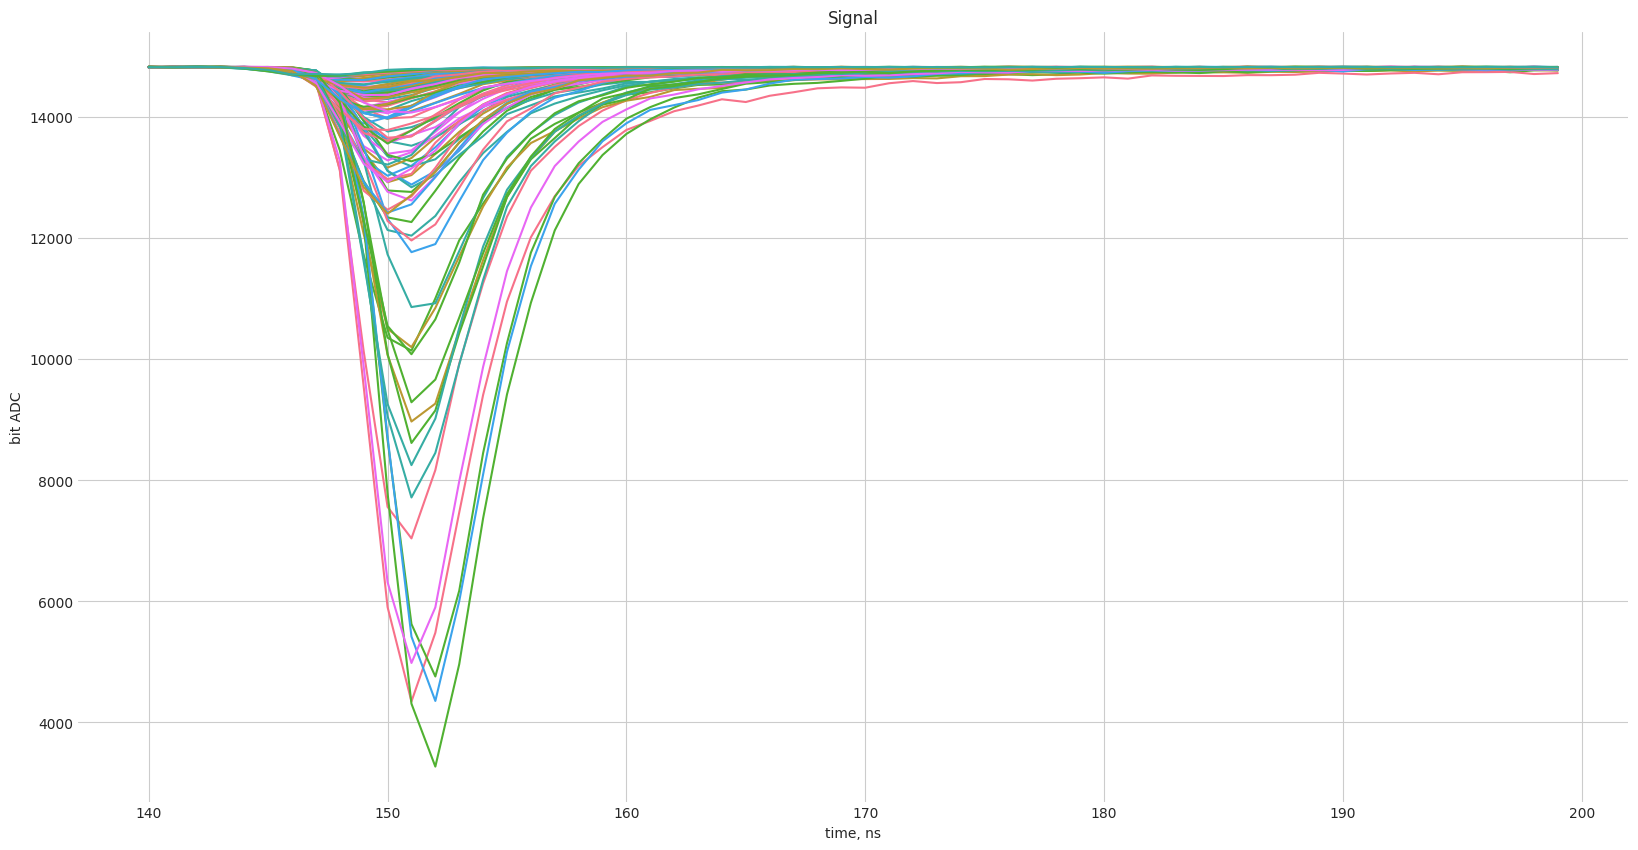

In [ ]:
N=range(0,100)
ax = dataset.T[N][140:200].plot(title='Signal' ,legend=None,figsize=(20,10))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")

Text(0, 0.5, 'bit ADC')

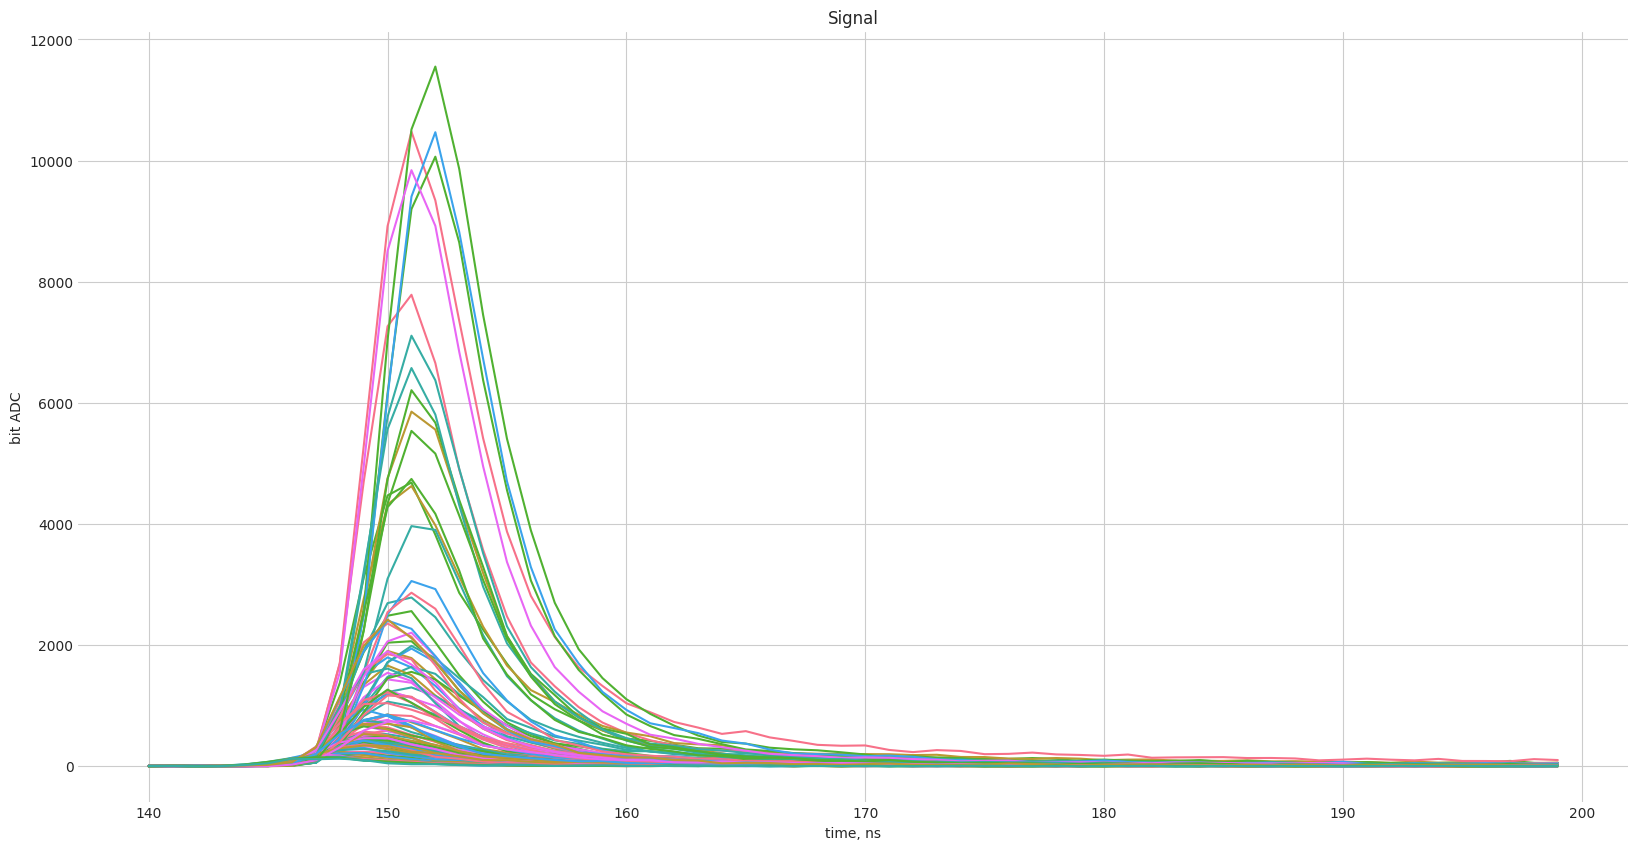

In [ ]:
ax = (2**14-dataset.T[N]-1560)[140:200].plot(title='Signal' ,legend=None,figsize=(20,10))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")


### Вывод:
- Размер данных: (23479, 500)
- Из графиков видно:
    - Значения падают от ~14828 до ~14815
    - Сигнал идёт вниз, а не вверх
    - Данные необычные: как правило, сигнал сцинтилляции — это положительный импульс, но здесь он отрицательный.
    > Это может быть связано со спецификой оборудования

    - Переворот делает сигнал "классическим" — положительный пик вверх

    - Из этого следует, что при извлечении признаков:
    - Максимум — это минимальное значение сигнала;
    - Амплитуда = базовый_уровень - min(сигнал);
    - Площадь нужно будет считать после инверсии.

## Базовый анализ данных

In [ ]:
signals = dataset.values
def quick_eda(signals, n_samples=100):
    """Быстрый EDA перед извлечением признаков"""
    baselines = [np.mean(sig[:50]) for sig in signals[:n_samples]]
    amplitudes = [np.max(baseline - sig) for sig, baseline in zip(signals[:n_samples], baselines)]

    print("Базовый EDA")
    print(f"Базовый уровень: mu={np.mean(baselines):.1f}, sigma={np.std(baselines):.1f}")
    print(f"Амплитуда: mu={np.mean(amplitudes):.1f}, sigma={np.std(amplitudes):.1f}")
    print(f"amplitude_min = {np.min(amplitudes):.1f}")
    print(f"amplitude_max = {np.max(amplitudes):.1f}")

quick_eda(signals, n_samples=100)

Базовый EDA
Базовый уровень: mu=14822.3, sigma=0.7
Амплитуда: mu=1874.3, sigma=2567.1
amplitude_min = 121.9
amplitude_max = 11550.6


### Вывод:
- шум: стабильные значения - разброс минимальный sigma=0.7
- Большой разброс амплитуд — возможно, есть два типа сигналов:
  - Средние амплитуды (гамма) - кластер 0
  - Высокие амплитуды (нейтроны) - кластер 1
  - Низкие амплитуды (шум/артефакты) - кластер 2
- amplitude_min = 122	Есть очень маленькие сигналы (почти шум)
- Разброс амплитуд настолько велик, что алгоритмы (KMeans, PCA) - должны хорощо сработать

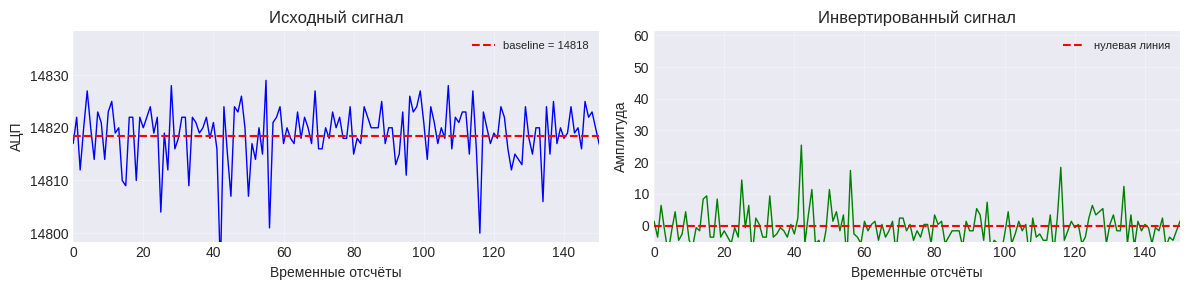

Базовый уровень: 14818.4
Амплитуда: 56.4


In [ ]:
# Берём первый сигнал (индекс 0)
one_signal = dataset[250]

# Инверсия сигнала
baseline = np.mean(one_signal[:50])  # базовый уровень (шум)
signal_inverted = baseline - one_signal

# Визуализация (один график, компактно)
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

# исходный сигнал
axes[0].plot(one_signal, 'b-', linewidth=1)
axes[0].axhline(y=baseline, color='r', linestyle='--', label=f'baseline = {baseline:.0f}')
axes[0].set_title('Исходный сигнал')
axes[0].set_xlabel('Временные отсчёты')
axes[0].set_ylabel('АЦП')
axes[0].set_ylim(baseline - 20, baseline + 20)
axes[0].set_xlim(0, 150)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# инвертированный сигнал
axes[1].plot(signal_inverted, 'g-', linewidth=1)
axes[1].axhline(y=0, color='r', linestyle='--', label='нулевая линия')
axes[1].set_title('Инвертированный сигнал')
axes[1].set_xlabel('Временные отсчёты')
axes[1].set_ylabel('Амплитуда')
axes[1].set_ylim(-5, signal_inverted.max() + 5)
axes[1].set_xlim(0, 150)
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Базовый уровень: {baseline:.1f}")
print(f"Амплитуда: {signal_inverted.max():.1f}")

Вывод:
- посмотрела сигнал без коррекции - для PCA надо скорректирровать, согласно методике:
> "Нулевой линией сигнала назовём среднее значение в левом хвосте кривой. Сигналом назовём подмножество значений кривой, содержащееся между максимумом и местом, где значение кривой начало отставать от нулевой линии на три стандартных отклонения"

- После корректировки - нулевой уровень выровнился (будем придерживаться этого пути)

## Извлечение признаков

In [ ]:
# Определим вспомогательные функции для извлечения признаков сигнала
def exponential_decay(t, a, tau, c):
    """Экспоненциальная аппроксимация с константой"""
    return a * np.exp(-t / tau) + c

def invert_signal(signal, noise_samples=50):
    """Инвертирует сигнал для удобства обработки"""
    baseline = np.mean(signal[:noise_samples])
    inverted = baseline - signal
    return inverted, baseline

def find_signal_end(signal_inv, noise_std, sigma_threshold=3, start_idx=0):
    """Находит конец сигнала по порогу"""
    threshold = sigma_threshold * noise_std
    end_idx = start_idx
    for i in range(start_idx, len(signal_inv)):
        if signal_inv[i] <= threshold:
            end_idx = i
            break
    return end_idx

def find_fit_start(pure_signal, amplitude, amplitude_fraction=0.4):
    """Находит точку для начала аппроксимации (отступ 40% от амплитуды)"""
    target_level = amplitude * (1 - amplitude_fraction)
    for i, val in enumerate(pure_signal):
        if val <= target_level:
            return i
    return 0

In [ ]:
def extract_features(signal, noise_samples=50, amplitude_fraction=0.4, short_gate=9):
    """Извлечение признаков из RAW сигнала
    Параметры:  signal - Временной ряд сигнала
                noise_samples - Количество отсчётов для оценки шума (первые 50)
                amplitude_fraction - Доля амплитуды для отступа (40% оптимально)
                short_gate - Длина short gate для PSD
    Аргументы: area - площадь под сигналом
    """
    signal = np.array(signal, dtype=float)

    # Оценка шума - преобразовываем исходные данные - invert_signal()
    signal_inv, baseline = invert_signal(signal, noise_samples)
    noise_std = np.std(signal[:noise_samples])

    # Поиск максимума
    idx_max = np.argmax(signal_inv)
    # Признак 1: amplitude
    amplitude = signal_inv[idx_max]

    # Находим порог сигнала - find_signal_end()
    idx_end = find_signal_end(signal_inv, noise_std, sigma_threshold=3, start_idx=idx_max)

    # Вырезаем чистый сигнал
    pure_signal = signal_inv[idx_max:idx_end+1]

    if len(pure_signal) < 10:
        return {'amplitude': amplitude, 'area': 0, 'decay_time': np.nan,
                'PSD': 0, 'baseline': baseline, 'noise_std': noise_std,
                'signal_length': len(pure_signal)
                }

    # Признак 2: площадь под сигналом
    area = np.trapz(pure_signal)

    # Находим точку для начала аппроксимации - find_fit_start()
    start_fit_idx = find_fit_start(pure_signal, amplitude, amplitude_fraction)

    # Признак 3: время высвечивания (аппроксимация экспонентой)
    decay_time = np.nan
    if start_fit_idx < len(pure_signal) - 5 and start_fit_idx > 0:
        decay_part = pure_signal[start_fit_idx:]
        t_fit = np.arange(len(decay_part))
        try:
            #  bounds (ограничения)
            popt, _ = curve_fit(
                exponential_decay, t_fit, decay_part,
                p0=[amplitude * amplitude_fraction, 20, 0],
                maxfev=2000,
                bounds=([0, 0, -np.inf], [np.inf, np.inf, np.inf])  # tau >= 0
            )
            decay_time = popt[1]  # tau (время высвечивания)
            # Отфильтровываем нереалистичные значения
            if decay_time < 0.1 or decay_time > 1000:
                decay_time = np.nan
        except:
            pass

    # Признак 4: PSD
    short_area = np.trapz(pure_signal[:short_gate])
    PSD = (area - short_area) / area if area > 0 else 0

    # Дополнительные статистики
    skewness = skew(pure_signal) if len(pure_signal) > 2 else 0
    kurt = kurtosis(pure_signal) if len(pure_signal) > 2 else 0

    return {
        'amplitude': amplitude,
        'area': area,
        'decay_time': decay_time,
        'PSD': PSD,
        'skewness': skewness,
        'kurtosis': kurt,
        # 'baseline': baseline,
        # 'noise_std': noise_std,
        # 'signal_length': len(pure_signal),
        # 'idx_max': idx_max,
        # 'idx_end': idx_end,
        # 'fit_start_idx': start_fit_idx
    }

### Побор оптимального short_gate

gate=  1: mean PSD=0.9890
gate=  5: mean PSD=0.3838
gate=  9: mean PSD=0.1885
gate= 10: mean PSD=0.1631
gate= 15: mean PSD=0.0899
gate= 20: mean PSD=0.0568
gate= 30: mean PSD=0.0282
gate= 40: mean PSD=0.0154


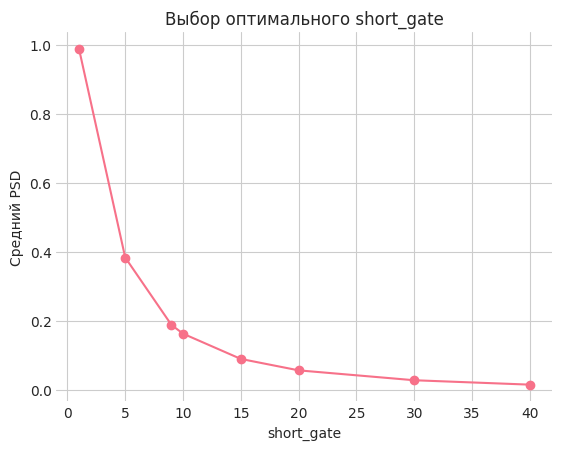

CPU times: user 1min 11s, sys: 121 ms, total: 1min 11s
Wall time: 1min 13s


In [ ]:
%%time
# Тестирование на части данных
gates = [1, 5, 9, 10, 15, 20, 30, 40]
means = []

for gate in gates:
    psds = []
    for sig in signals[:1000]:
        features = extract_features(sig, short_gate=gate)
        psds.append(features['PSD'])
    means.append(np.mean(psds))
    print(f"gate={gate:3}: mean PSD={np.mean(psds):.4f}")

# График
plt.plot(gates, means, marker='o')
plt.xlabel('short_gate')
plt.ylabel('Средний PSD')
plt.title('Выбор оптимального short_gate')
plt.grid(True)
plt.show()

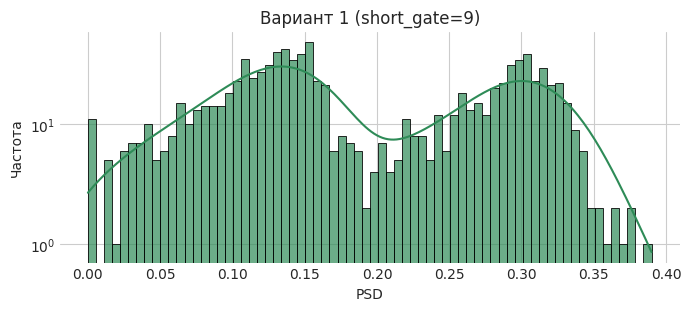

mean PSD=0.1885, std=0.0934


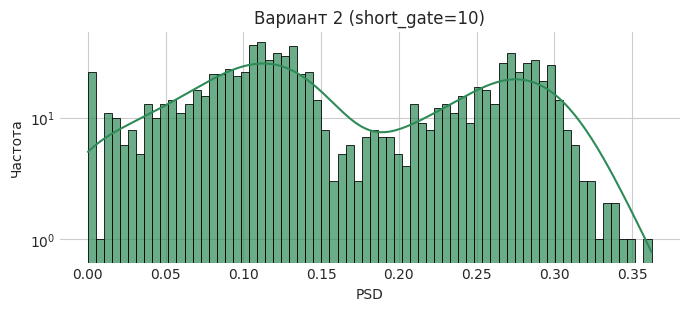

mean PSD=0.1631, std=0.0909


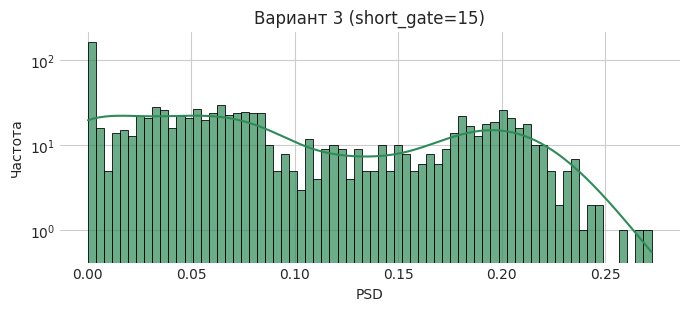

mean PSD=0.0899, std=0.0751


In [ ]:
# Функция для построения гистограммы PSD
def plot_psd_histogram(signals, gate, title):
    psds = []
    for sig in signals[:1000]:
        features = extract_features(sig, short_gate=gate)
        psds.append(features['PSD'])

    plt.figure(figsize=(8, 3))
    sns.set_style('whitegrid')
    sns.histplot(psds, bins=70, edgecolor='black' ,  color="seagreen", alpha=0.7, kde=True)
    plt.xlabel('PSD')
    plt.ylabel('Частота')
    plt.title(f'{title} (short_gate={gate})')
    plt.yscale('log')
    plt.show()

    print(f"mean PSD={np.mean(psds):.4f}, std={np.std(psds):.4f}")

# Сравним несколько вариантов
plot_psd_histogram(signals, gate=9, title="Вариант 1")
plot_psd_histogram(signals, gate=10, title="Вариант 2")
plot_psd_histogram(signals, gate=15, title="Вариант 3")

Вывод:
- Провела подбор short_gate на части данных.
- Видим, что перелом локтя идет в точках 9, 10 и может быть 15 - надо посмотреть сигналы
- Видим, что лучшее разделение пиков наблюдается при short_gate = 9 и 10:
    - short_gate = 9:	mean_PSD=0.1885, std=0.0934 -	хороший разброс, бимодальность, чуть лучше чувствительность.
    - short_gate = 10:	mean_PSD=0.1631, std=0.0909 - хороший разброс, бимодальность
    - short_gate = 15:	mean_PSD=0.0899, std=0.0751 - разброс уменьшается, хуже расперделение
- визуально на графиках тоже видим более яркие пики именно при short_gate = 9 и 10,
- возьмем в итоге short_gate = 9 (short_gate = 10 можно рассматривать как альтернативный вариант)

In [ ]:
signals.shape

(23479, 500)

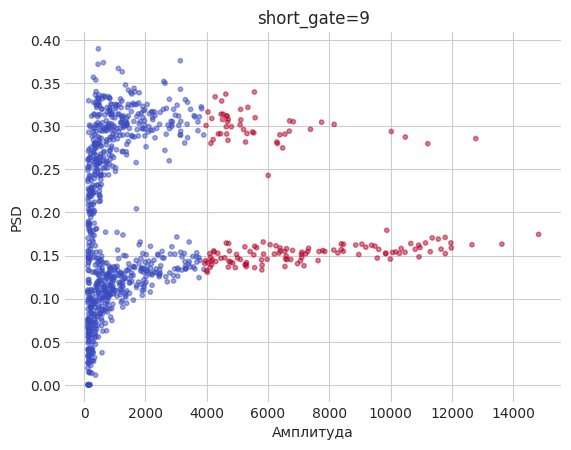

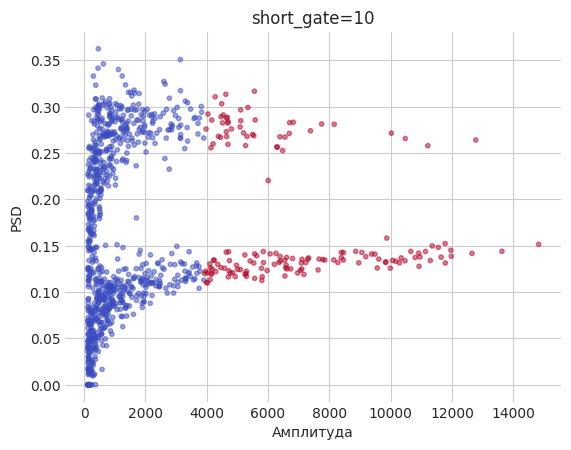

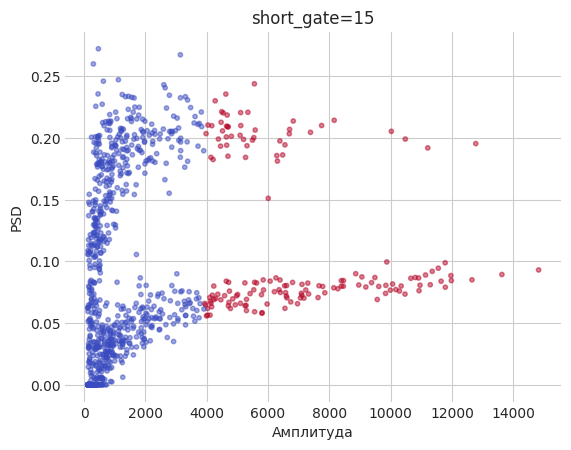

In [ ]:
# проверим качество кластеризации на части данных
for gate in [9, 10, 15]:
    psd_values = []
    amplitudes = []

    for sig in signals[:1000]:
        f = extract_features(sig, short_gate=gate)
        psd_values.append(f['PSD'])
        amplitudes.append(f['amplitude'])

    # Кластеризация по PSD и амплитуде
    X = np.column_stack([amplitudes, psd_values])
    kmeans = KMeans(n_clusters=2, random_state=42)
    labels = kmeans.fit_predict(X)

    plt.scatter(amplitudes, psd_values, cmap='coolwarm', c=labels, alpha=0.5, s=10)
    plt.xlabel('Амплитуда')
    plt.ylabel('PSD')
    plt.title(f'short_gate={gate}')
    plt.show()

Вывод:
- Хорошее разделение и при short_gate=9, и при short_gate=10, при short_gate=15 - уже хуже
- Больший разброс PSD наблюдается при при 9 - чуть более чувствительное разделение
- Два кластера визуально более разделены:
   - Кластер 2 с наибольшей амплитудой (красные) - Нейтроны (A>4000) - чуть выше, чес в документации
   - Кластер 1 со средней амплитудой - Гамма-кванты (A>500-4000)
   - Кластер 0 с минимальной амплитудой - Шум/артефакты

- Выбираем short_gate=9, как более информативный, выделим признаки по всему датасету с выбранным параметром.

### Извлечение признаков

In [ ]:
%%time
# извлечение признаков
SHORT_GATE = 10
#SHORT_GATE = 9
features_list = []

for i in range(len(signals)):
    features = extract_features(signals[i], short_gate=SHORT_GATE )
    features_list.append(features)

# Создаём DataFrame
df_features = pd.DataFrame(features_list)
df_features.columns

CPU times: user 3min 18s, sys: 266 ms, total: 3min 19s
Wall time: 3min 29s


Index(['amplitude', 'area', 'decay_time', 'PSD', 'skewness', 'kurtosis',
       'baseline', 'noise_std', 'signal_length'],
      dtype='object')

## Анализ данных

In [ ]:
def express_info(data, name='train', nans = True):
    '''Функция первичного исследования данных:
          - структура данных
          - пропуски
          - явные дубликаты
          - статистическое описание данных
       Аргументы:
          - data - датафрейм
          - name - название таблицы
          - nans флаг (True - результат пропущенных данных по столбцам)
    '''
    print(f'Размер данных ({name}):      {data.shape}')
    print(f'Количество явных дубликатов: {data.duplicated().sum()}')
    print(f'Наличие пропусков:           {data.isna().sum().sum()}')
    if nans:
        print(f'\nПропущенные данные:')
        #print(round(data.isna().mean()*100).sort_values(ascending=False).head(7), sep = '\n')
        print(data.isna().sum().sort_values(ascending=False).head(15), sep = '\n')
    print(f'\nИнформация ({name}):')
    data.info()
    display(data.head(5))
    display(data.describe().T)
    print()

express_info(df_features, name='df_features', nans = True)

Размер данных (df_features):      (23479, 9)
Количество явных дубликатов: 0
Наличие пропусков:           70528

Пропущенные данные:
noise_std        23264
baseline         23264
signal_length    23264
decay_time         306
skewness           215
kurtosis           215
amplitude            0
PSD                  0
area                 0
dtype: int64

Информация (df_features):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23479 entries, 0 to 23478
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   amplitude      23479 non-null  float64
 1   area           23479 non-null  float64
 2   decay_time     23173 non-null  float64
 3   PSD            23479 non-null  float64
 4   skewness       23264 non-null  float64
 5   kurtosis       23264 non-null  float64
 6   baseline       215 non-null    float64
 7   noise_std      215 non-null    float64
 8   signal_length  215 non-null    float64
dtypes: float64(9)
memory usa

,amplitude,area,decay_time,PSD,skewness,kurtosis,baseline,noise_std,signal_length
0,530.48,2588.02,3.574021,0.183615,1.673924,1.668128,NaN,NaN,NaN
1,1901.48,8489.74,2.940328,0.114776,2.420751,4.717308,NaN,NaN,NaN
2,2557.90,9252.90,2.915773,0.126317,2.703201,6.566386,NaN,NaN,NaN
3,564.56,3084.48,3.350594,0.209416,2.071777,3.048226,NaN,NaN,NaN
4,1793.60,7695.00,2.948218,0.115478,2.116224,3.251083,NaN,NaN,NaN


,count,mean,std,min,25%,50%,75%,max
amplitude,23479.0,1835.104716,2389.300501,104.300000,308.160000,812.540000,2315.050000,14824.840000
area,23479.0,8567.775444,10841.517592,0.000000,1410.160000,3874.700000,11346.890000,88056.960000
decay_time,23173.0,3.948643,8.670712,0.357874,2.921052,3.493617,4.258400,833.118202
PSD,23479.0,0.167628,0.091481,0.000000,0.095988,0.138487,0.261907,0.390438
skewness,23264.0,2.266587,1.111798,-0.076464,1.394255,2.022220,3.030289,6.384639
kurtosis,23264.0,5.495704,6.622367,-1.660779,0.661636,3.001813,8.580933,43.438918
baseline,215.0,14822.903721,0.827190,14820.260000,14822.370000,14822.920000,14823.400000,14825.480000
noise_std,215.0,2.747906,0.253720,1.959184,2.587855,2.741970,2.918388,3.378520
signal_length,215.0,8.748837,0.485477,7.000000,9.000000,9.000000,9.000000,9.000000


Вывод:
- Видим пропуски в данных - decay_time, idx_end, idx_max, fit_start_idx, skewness, kurtosis
- Пропуски связаны с короткими/зашумлёнными сигналами, которые не удалось корректно обработать.
- decay_time: заполним медианой (важно для кластеризации)
- skewness/kurtosis:  0 (симметричный сигнал)
- остальные колонки нам не столь важны для кластеризации не будем их использовать.

In [ ]:
# наборы данных
df_base = df_features[['amplitude', 'area', 'decay_time', 'PSD']].copy()
df_full = df_features[['amplitude', 'area', 'decay_time', 'PSD', 'skewness', 'kurtosis']].copy()
express_info(df_base, name='df_features', nans = True)
#df_base.describe().T

Размер данных (df_features):      (23479, 4)
Количество явных дубликатов: 3
Наличие пропусков:           306

Пропущенные данные:
decay_time    306
amplitude       0
area            0
PSD             0
dtype: int64

Информация (df_features):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23479 entries, 0 to 23478
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   amplitude   23479 non-null  float64
 1   area        23479 non-null  float64
 2   decay_time  23173 non-null  float64
 3   PSD         23479 non-null  float64
dtypes: float64(4)
memory usage: 733.8 KB


,amplitude,area,decay_time,PSD
0,530.48,2588.02,3.574021,0.183615
1,1901.48,8489.74,2.940328,0.114776
2,2557.90,9252.90,2.915773,0.126317
3,564.56,3084.48,3.350594,0.209416
4,1793.60,7695.00,2.948218,0.115478


,count,mean,std,min,25%,50%,75%,max
amplitude,23479.0,1835.104716,2389.300501,104.300000,308.160000,812.540000,2315.050000,14824.840000
area,23479.0,8567.775444,10841.517592,0.000000,1410.160000,3874.700000,11346.890000,88056.960000
decay_time,23173.0,3.948643,8.670712,0.357874,2.921052,3.493617,4.258400,833.118202
PSD,23479.0,0.167628,0.091481,0.000000,0.095988,0.138487,0.261907,0.390438


In [ ]:
express_info(df_full, name='df_features', nans = True)

Размер данных (df_features):      (23479, 6)
Количество явных дубликатов: 3
Наличие пропусков:           736

Пропущенные данные:
decay_time    306
skewness      215
kurtosis      215
amplitude       0
area            0
PSD             0
dtype: int64

Информация (df_features):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23479 entries, 0 to 23478
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   amplitude   23479 non-null  float64
 1   area        23479 non-null  float64
 2   decay_time  23173 non-null  float64
 3   PSD         23479 non-null  float64
 4   skewness    23264 non-null  float64
 5   kurtosis    23264 non-null  float64
dtypes: float64(6)
memory usage: 1.1 MB


,amplitude,area,decay_time,PSD,skewness,kurtosis
0,530.48,2588.02,3.574021,0.183615,1.673924,1.668128
1,1901.48,8489.74,2.940328,0.114776,2.420751,4.717308
2,2557.90,9252.90,2.915773,0.126317,2.703201,6.566386
3,564.56,3084.48,3.350594,0.209416,2.071777,3.048226
4,1793.60,7695.00,2.948218,0.115478,2.116224,3.251083


,count,mean,std,min,25%,50%,75%,max
amplitude,23479.0,1835.104716,2389.300501,104.300000,308.160000,812.540000,2315.050000,14824.840000
area,23479.0,8567.775444,10841.517592,0.000000,1410.160000,3874.700000,11346.890000,88056.960000
decay_time,23173.0,3.948643,8.670712,0.357874,2.921052,3.493617,4.258400,833.118202
PSD,23479.0,0.167628,0.091481,0.000000,0.095988,0.138487,0.261907,0.390438
skewness,23264.0,2.266587,1.111798,-0.076464,1.394255,2.022220,3.030289,6.384639
kurtosis,23264.0,5.495704,6.622367,-1.660779,0.661636,3.001813,8.580933,43.438918


In [ ]:
def feed_size(data, feature = 'amplitude', name_feature = 'Амплитуда', x_lim=None):
    #print(f'Данные распределением и аномалиям по {feature}')
    print(f'\nСтатистические данные о распределении значений ({name_feature}):\n')
    #display(data[feature].describe())
    plt.figure(figsize=[10, 3])
    plt.title(f'Гистограмма распределения значений ({name_feature}):')
    sns.set_style('whitegrid')
    sns.histplot(data[feature], bins=90 ,  color="seagreen", label=f'{name_feature}', alpha=0.7, kde=True)
    plt.xlabel(f'{name_feature}')
    plt.ylabel(f'Частота')
    plt.legend(loc='upper right', fontsize='large')
    plt.show()

    plt.figure(figsize=(10, 2))
    plt.title(f'\nДиаграмма рассеяния {name_feature}')
    sns.boxplot(x=data[feature], palette='pastel')
    plt.show()


Статистические данные о распределении значений (Амплитуда):



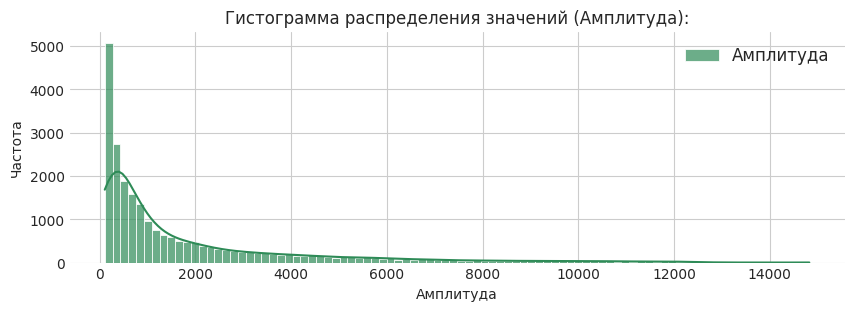

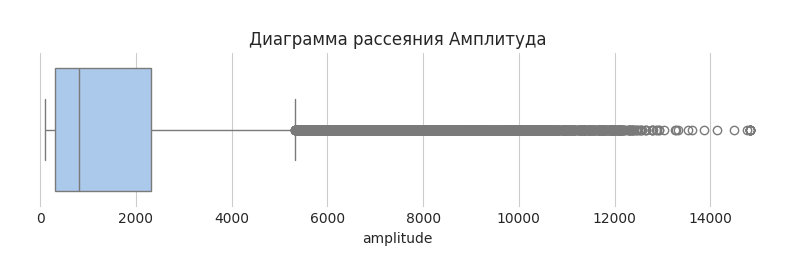


Статистические данные о распределении значений (area):



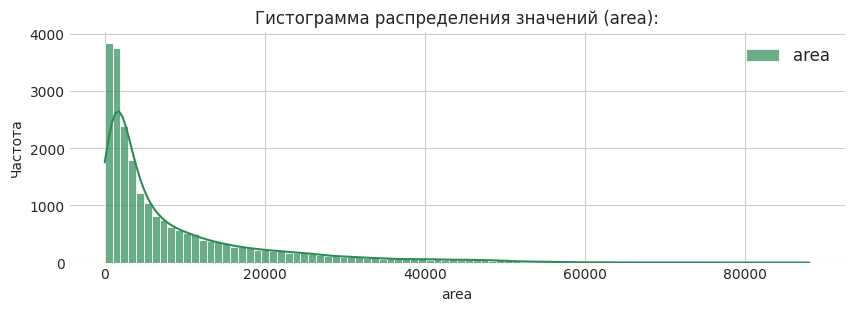

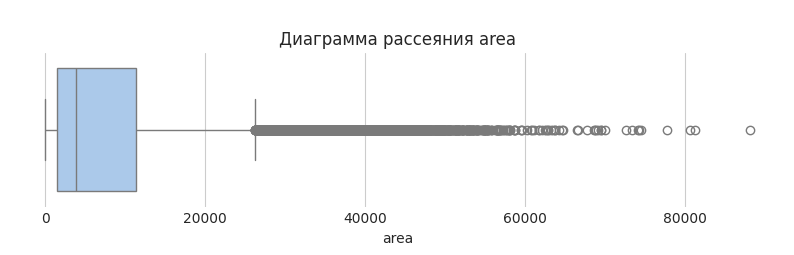


Статистические данные о распределении значений (PSD):



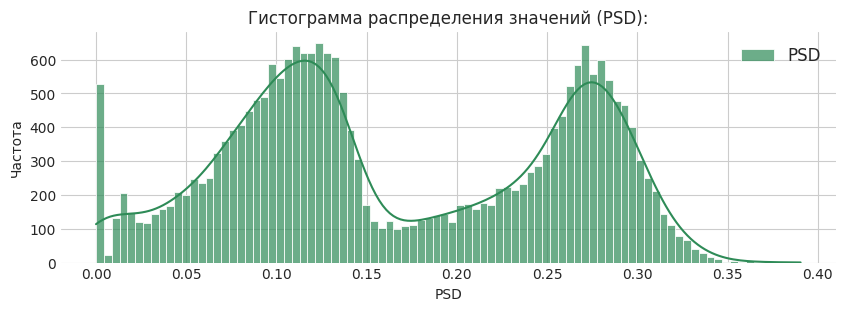

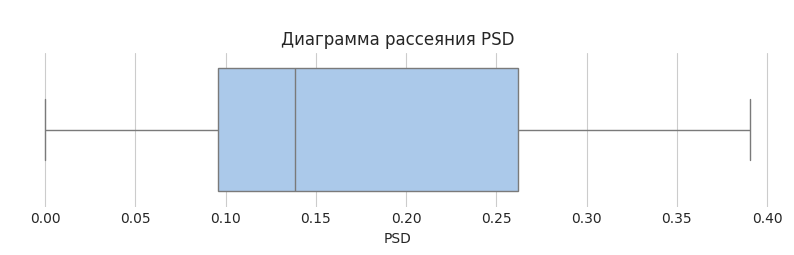


Статистические данные о распределении значений (decay_time):



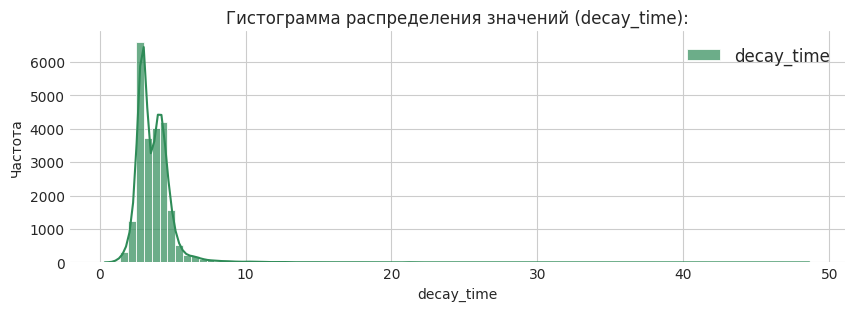

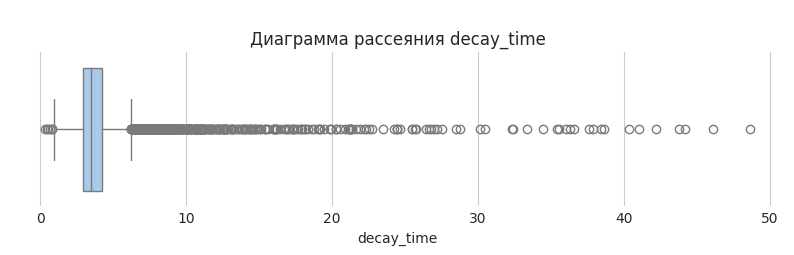


Статистические данные о распределении значений (длина сигнала):



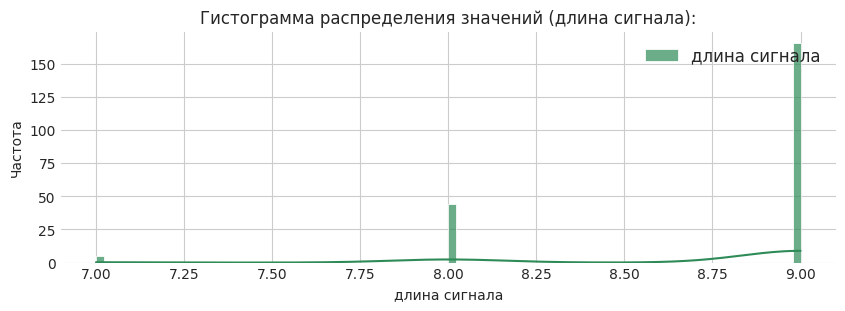

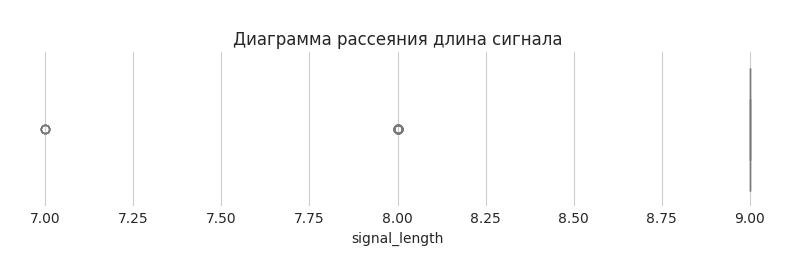

In [ ]:
feed_size(df_base)
feed_size(df_base, feature = 'area', name_feature = 'area')
feed_size(df_base, feature = 'PSD', name_feature = 'PSD')
feed_size(df_base[df_base['decay_time'] < 50], feature = 'decay_time', name_feature = 'decay_time', x_lim=200)
feed_size(df_features, feature = 'signal_length', name_feature = 'длина сигнала')
# feed_size(df_full, feature = 'kurtosis', name_feature = 'kurtosis')
# feed_size(df_full, feature = 'skewness', name_feature = 'Ассиметрия')

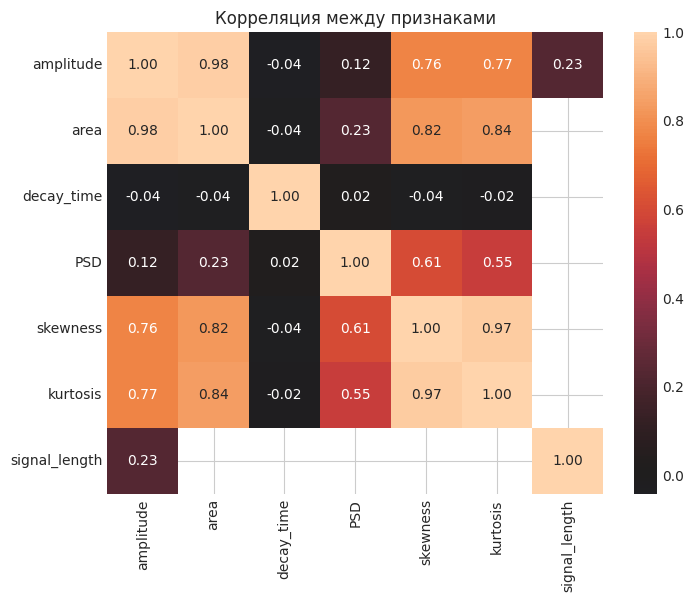

In [ ]:
# Считаем матрицу корреляций

corr = df_features[['amplitude', 'area', 'decay_time', 'PSD',
                           'skewness', 'kurtosis', 'signal_length']].corr()#.abs()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, center=0, fmt='.2f')  #cmap='coolwarm'
plt.title("Корреляция между признаками")
plt.show()

<Figure size 1200x1000 with 0 Axes>

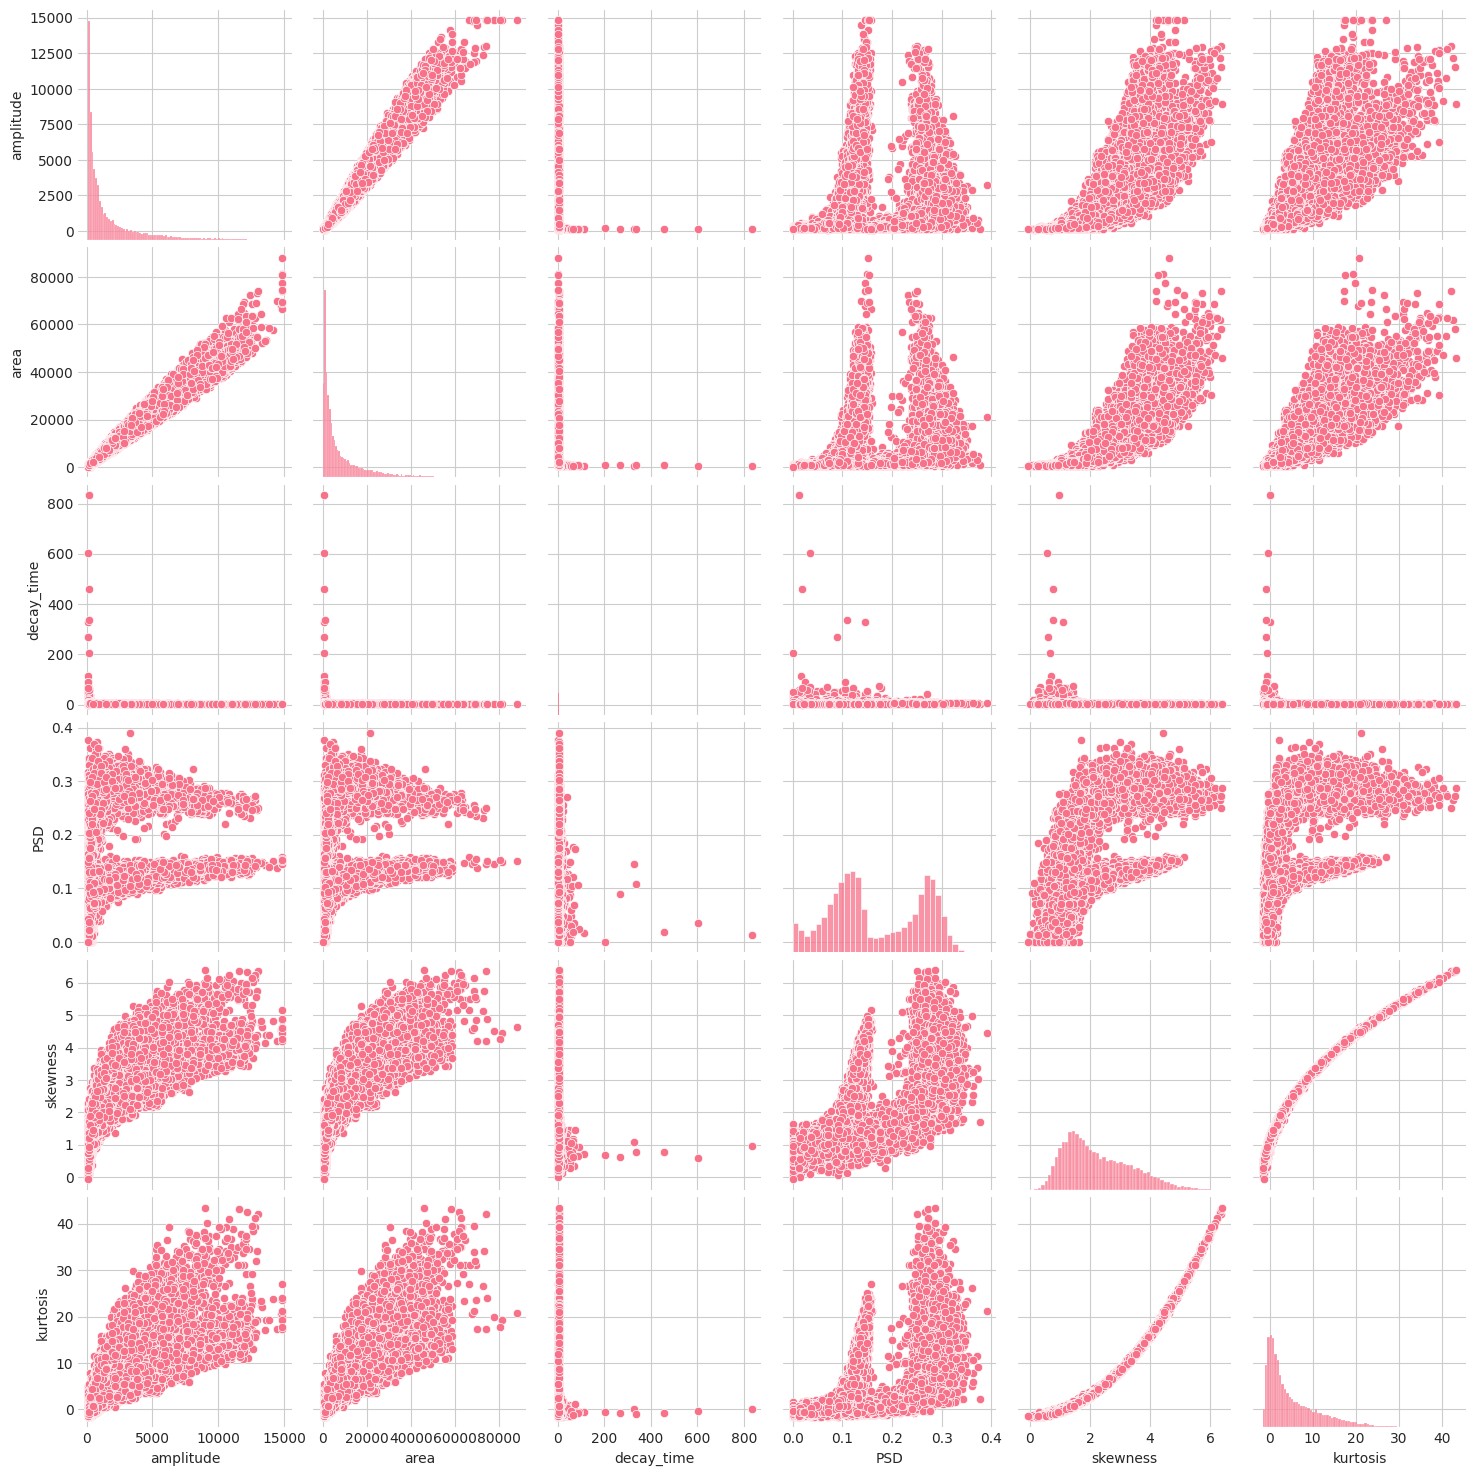

In [ ]:
plt.figure(figsize=(12, 10))

sns.pairplot(df_features[['amplitude', 'area', 'decay_time', 'PSD', 'skewness', 'kurtosis']])
plt.show();

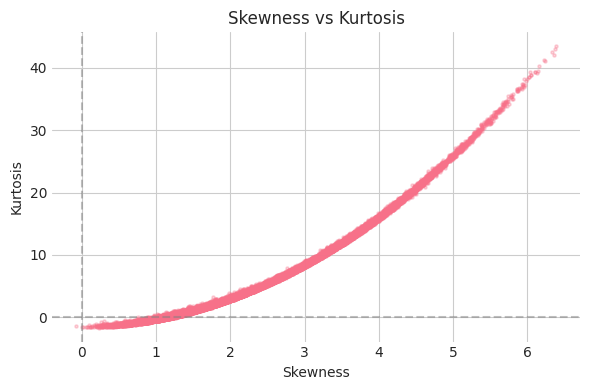

In [ ]:
#Skewness vs Kurtosis (scatter)
plt.subplots(figsize=(6, 4))
plt.scatter(df_features['skewness'], df_features['kurtosis'], alpha=0.3, s=5)
plt.xlabel('Skewness')
plt.ylabel('Kurtosis') #sns
plt.title('Skewness vs Kurtosis')
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
df_full.describe().T

,count,mean,std,min,25%,50%,75%,max
amplitude,23479.0,1835.104716,2389.300501,104.300000,308.160000,812.540000,2315.050000,14824.840000
area,23479.0,8567.775444,10841.517592,0.000000,1410.160000,3874.700000,11346.890000,88056.960000
decay_time,23173.0,3.948643,8.670712,0.357874,2.921052,3.493617,4.258400,833.118202
PSD,23479.0,0.167628,0.091481,0.000000,0.095988,0.138487,0.261907,0.390438
skewness,23264.0,2.266587,1.111798,-0.076464,1.394255,2.022220,3.030289,6.384639
kurtosis,23264.0,5.495704,6.622367,-1.660779,0.661636,3.001813,8.580933,43.438918


#### Вывод:
- decay_time: mean=3.95 - большинство сигналов имеют быстрое высвечивание (затухание);
- decay_time max = 833	- есть редкие сигналы с очень медленным спадом (возможно это нейтроны)
- mean_PSD = 0.168 (соответсвует документации) - видим ярко выраженные 2 пика;
- amplitude и area:	распределение сильно скошено вправо
- skewness_mean = 2.246 (асимметрия):
  - Сильная скошеность данных вправо
  -большой разброс - есть разные типы сигналов
- kurtosis_mean = 5.45 (эксцесс) - острые пики (тяжёлые хвосты)
- kurtosis коррелирует с skewness	- более асимметричные сигналы имеют более острые пики
- есть выбросы (kurtosis > 40) - возможно, нейтроны или артефакты
- признаки (skewness и kurtosis) можно использовать для кластеризации - добавим их к базовым признакам.
- логичная корреляция area и signal_length.
- анализ даннх говорит о наличии кластеров - будем их разделять.
- рассмотрим 2 набора признаков, прологарифмируем признаки, постараемся нормализовать:
  - Базовый набор
  > df_base = ['amplitude', 'area', 'PSD', 'decay_time']

  - Со статистическими признаками
  > df_full = ['amplitude', 'area', 'PSD', 'decay_time', 'skewness', 'kurtosis']
- обнаружилось 3 дублирующих значения - они не влияют, оставим их, так как природу не знаем - это шум или качественные значения

## Подготовка данных и Feature Engineering

In [ ]:
def clean_features(data):
    """Очистка признаков от пропусков
     - decay_time: заполняем медианой
     - skewness/kurtosis: 0 означает симметричное распределение
    """
    df_clean = data.copy()

    median_decay = df_clean['decay_time'].median()
    df_clean['decay_time'] = df_clean['decay_time'].fillna(median_decay)
    median_amplitude = df_clean['amplitude'].median()
    df_clean['amplitude'] = df_clean['amplitude'].fillna(median_amplitude)


    df_clean['skewness'] = df_clean['skewness'].fillna(0)
    df_clean['kurtosis'] = df_clean['kurtosis'].fillna(0)

    return df_clean

df_clean = clean_features(df_features)
print(f"Пропусков после: {df_clean[['amplitude', 'area', 'PSD', 'decay_time', 'skewness', 'kurtosis']].isnull().sum().sum()}")

Пропусков после: 0


In [ ]:
# Подготовка 4х наборов признаков
df_base = df_clean[['amplitude', 'area', 'decay_time', 'PSD']].copy()
df_full = df_clean[['amplitude', 'area', 'PSD', 'decay_time', 'skewness', 'kurtosis']].copy()

# df_base.isnull().sum().sum()
# df_full.isnull().sum()

In [ ]:
def create_features(data, data_name = 'df_base_log'):
    """ Обработка признаков и создание новых на основе существующих
    """
    df = data.copy()
    # Логарифмирование (для нормализации распределений)
    df['log_amplitude'] = np.log1p(df['amplitude'])
    df['log_area'] = np.log1p(df['area'])
    df['log_decay'] = np.log1p(df['decay_time'])

    # Тригонометрические преобразования (для циклических)
    #df['psd_sin'] = np.sin(df['PSD'] * np.pi)
    # качественный параметр - ширина сигнала:
    df['area_per_amplitude'] = df['area'] / (df['amplitude'] + 1)

    print(f"Исходных признаков: {data.shape[1]}")
    print(f"Количество признаков в '{data_name}': {df.shape[1]}")
    print(f"Добавлено новых признаков: {df.shape[1] - data.shape[1]}")
    return df

In [ ]:
df_base = df_clean[['amplitude', 'area', 'PSD', 'decay_time']].copy()
df_base_log = create_features(df_base)

Исходных признаков: 4
Количество признаков в 'df_base_log': 8
Добавлено новых признаков: 4


In [ ]:
df_full_log = create_features(df_full, 'df_full_log')

Исходных признаков: 6
Количество признаков в 'df_full_log': 10
Добавлено новых признаков: 4


### Проверка наборов данных на корреляцию

In [ ]:
#напишем функцию для исследования данных
def research(data, name='train data', figsize=(12,8), silent=False):
    # Выбор только числовых столбцов
    numeric_data = data.select_dtypes(include=[np.number])
    col_cat = data.select_dtypes(include=['object', 'category']).columns
    if not silent:
        print(f'\nПроверка структуры {name}:')
        numeric_data.hist(linewidth=1, bins=30, figsize=figsize, edgecolor='black') # histtype='step'
        plt.suptitle(f'Гистограмма распределения {name}', y=0.98, fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    #тепловая карта корреляций
    corr_data = numeric_data.corr()
    print()
    plt.figure(figsize=figsize)
    matrix = np.triu(numeric_data.corr())
    heatmap = sns.heatmap(corr_data, annot=True, fmt='.2g',
                      mask=matrix, square=True, cmap='GnBu',  cbar=False,
                      linecolor='white',linewidths=1, annot_kws={"size": 8},   #cmap="YlGnBu"
                      xticklabels=True, yticklabels=True , vmin=0, vmax=1, center= 0)

    #plt.savefig('correlation_matrix.png', dpi=150)
    plt.suptitle(f'Тепловая карта матрицы корреляции {name}', y=0.90, fontsize=11)
    # Уменьшаем шрифт подписей осей на тепловой карте
    #plt.xticks(fontsize=9)
    plt.show()
    # print('Матрица корреляции')
    # display(corr_data)
    # display(numeric_data.describe().T)
    # if silent:
    #     print(f'Размер данных:      {numeric_data.shape}')
    #     print(f'Количество явных дубликатов: {numeric_data.duplicated().sum()}')
    #     print(f'Наличие пропусков:           {numeric_data.isna().sum().sum()}')
    #     display(data.head(3))


Проверка структуры df_base_log:


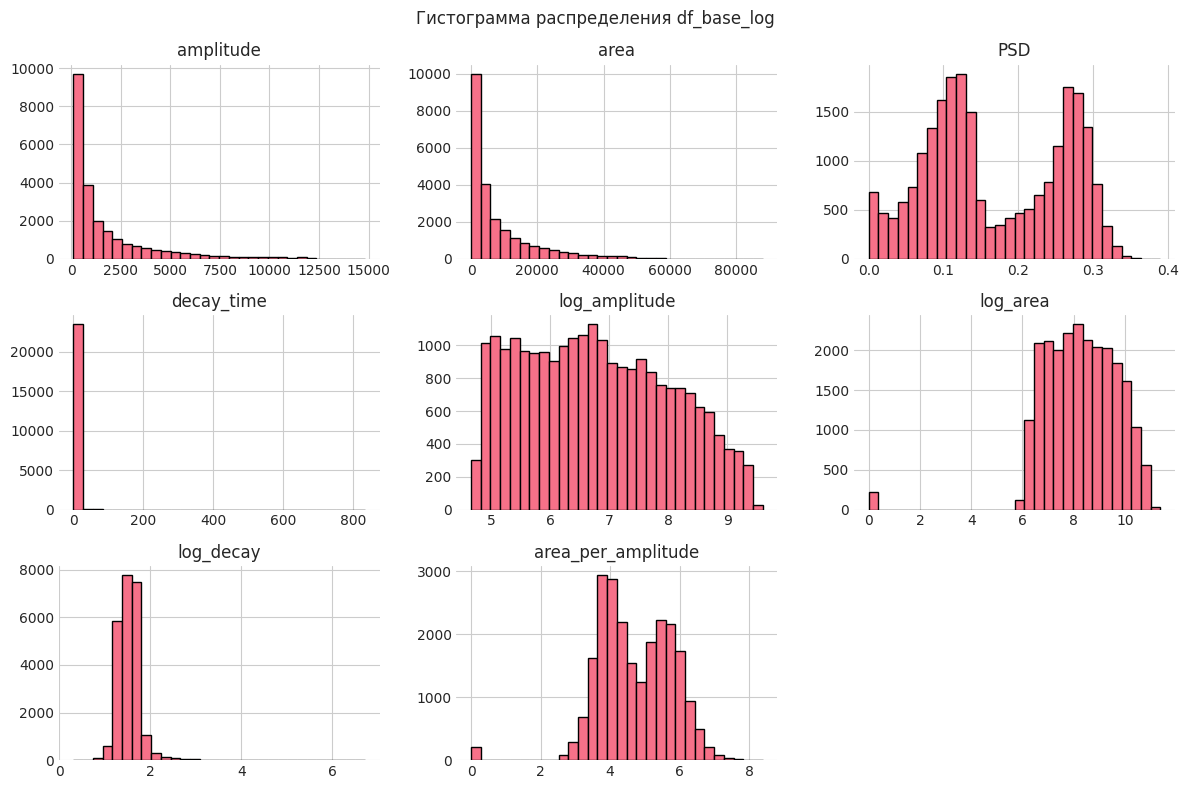

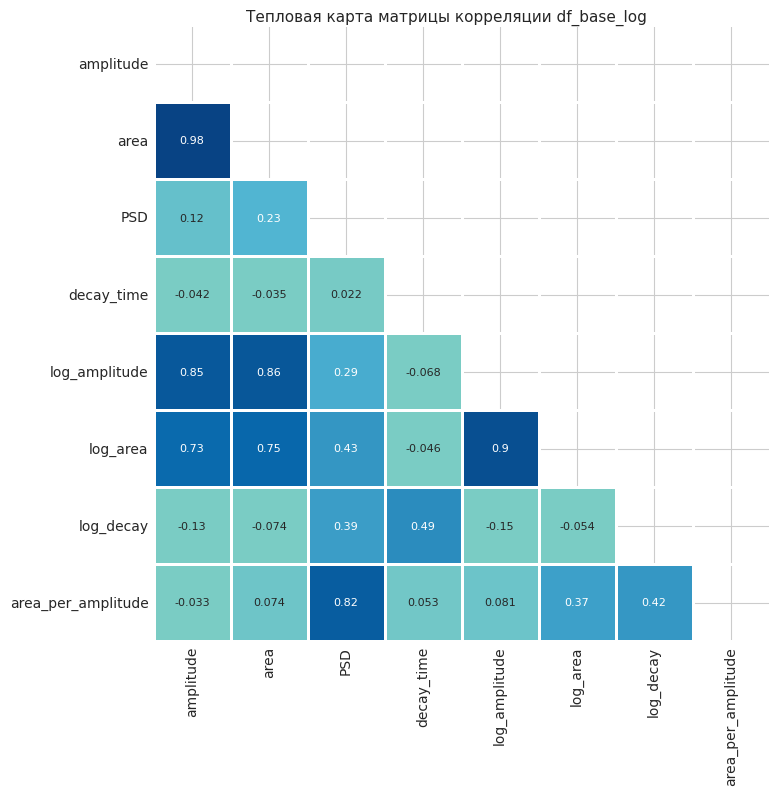

In [ ]:
research(df_base_log, name ='df_base_log')


Проверка структуры df_full_log:


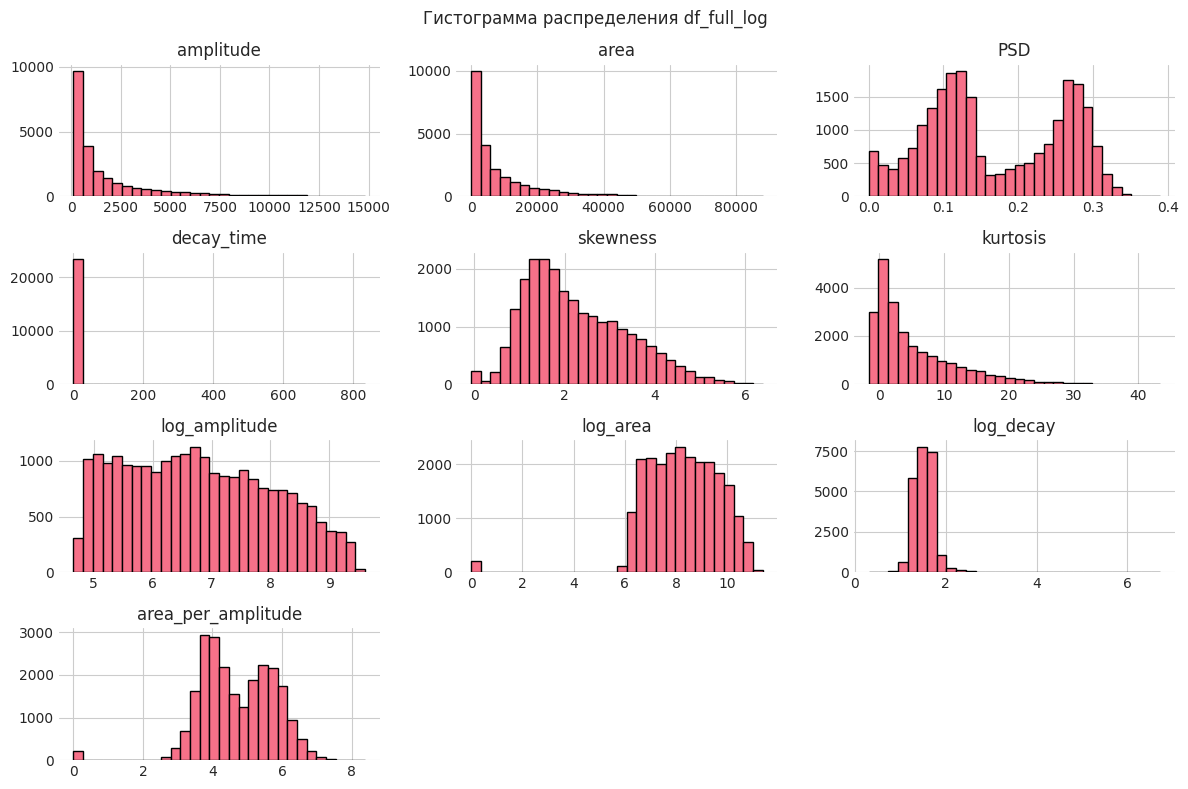

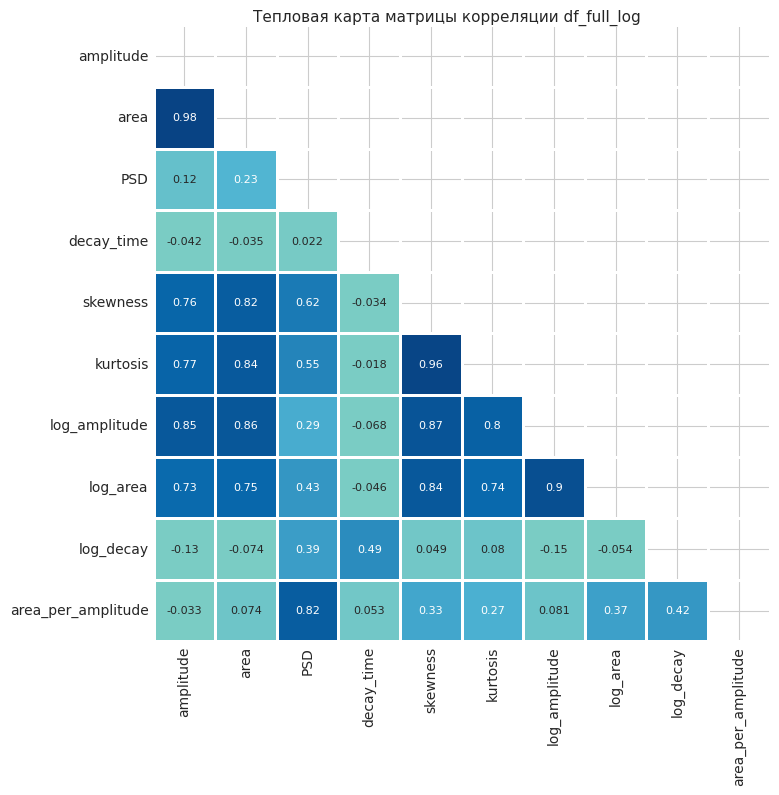

In [ ]:
research(df_full_log, name ='df_full_log')

Вывод:
- видим довольно сильную линейную корреляцию между между признаками амплитуды и площади, что ожидаемо, а такжде их тпроизводными,
- также слильная связь между 'skewness', 'kurtosis', что также ожидаемо
- качественный признак 'area_per_amplitude' - мало коррелирует с другими признаками, кроме 'PSD', но тоже не критичная связь,
- оставляем все, потом будем проверять на важность.

In [ ]:
df_full_log.columns

Index(['amplitude', 'area', 'PSD', 'decay_time', 'skewness', 'kurtosis',
       'log_amplitude', 'log_area', 'log_decay', 'area_per_amplitude'],
      dtype='object')

## Обучение модели

In [ ]:
def train_model(data, name_data = 'df_base'):
    # Стандартизация и pca
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(data)

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    print(f"Число выбранных компонент {name_data}:", pca.explained_variance_ratio_)
    print(f"Среднее значение {name_data}: pca = {pca.explained_variance_ratio_.sum():.3f}")
    # Кластеризация
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca)

    return X_pca, pca, kmeans, labels

In [ ]:
df_full_log1 = df_full_log[['amplitude', 'area', 'PSD', 'decay_time', 'skewness', 'kurtosis',\
       'log_amplitude', 'log_area', 'area_per_amplitude']].copy()

In [ ]:
X_pca, pca, kmeans, labels = train_model(df_base)
X_pca_l, pca_l, kmeans_l, labels_l = train_model(df_base_log, 'df_log')

X_pca_f, pca_f, kmeans_f, labels_f = train_model(df_full, 'df_full')
X_pca_fl, pca_fl, kmeans_fl, labels_fl = train_model(df_full_log, 'df_f_log')
X_pca_fl1, pca_fl1, kmeans_fl1, labels_fl1 = train_model(df_full_log1, 'df_f_log1')

Число выбранных компонент df_base: [0.51075941 0.25371126]
Среднее значение df_base: pca = 0.764
Число выбранных компонент df_log: [0.46434238 0.27170838]
Среднее значение df_log: pca = 0.736
Число выбранных компонент df_full: [0.63043947 0.17753832]
Среднее значение df_full: pca = 0.808
Число выбранных компонент df_f_log: [0.54427207 0.21899867]
Среднее значение df_f_log: pca = 0.763
Число выбранных компонент df_f_log1: [0.60471671 0.19741542]
Среднее значение df_f_log1: pca = 0.802


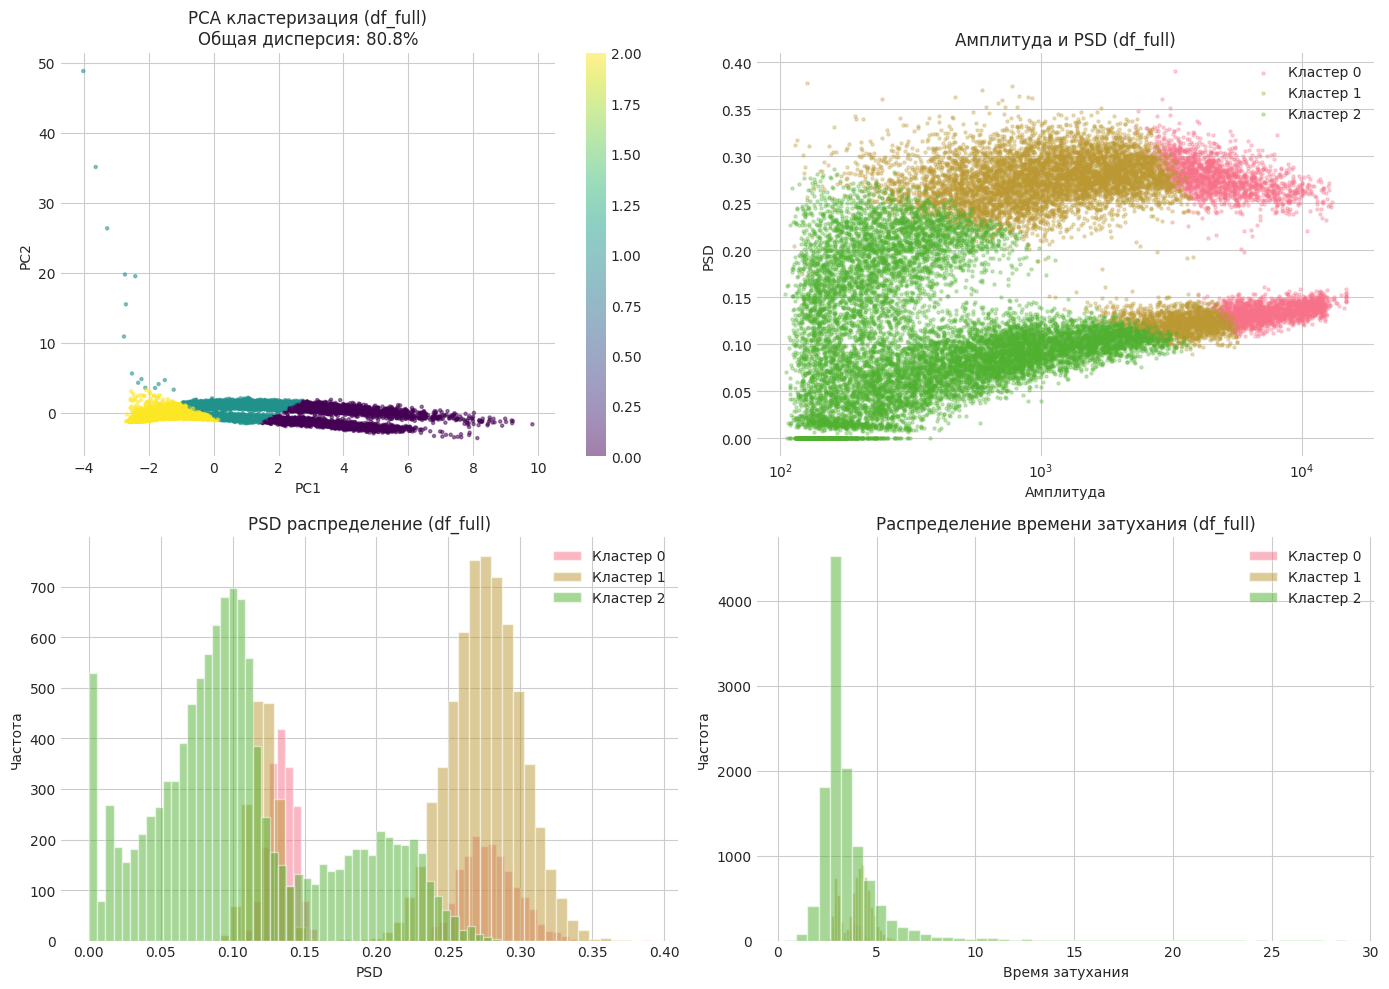

In [ ]:
def plot_pca_loadings(df_base, X_pca, labels, pca, name = 'df_base'):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # PCA
    scatter = axes[0, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=labels,
                                  cmap='viridis', alpha=0.5, s=5)
    axes[0, 0].set_xlabel('PC1')
    axes[0, 0].set_ylabel('PC2')
    axes[0, 0].set_title(f'PCA кластеризация ({name})\nОбщая дисперсия: {pca.explained_variance_ratio_.sum()*100:.1f}%')
    plt.colorbar(scatter, ax=axes[0, 0])

    # Амплитуда и PSD
    for cluster in range(3):
        mask = labels == cluster
        axes[0, 1].scatter(df_base.loc[mask, 'amplitude'],
                          df_base.loc[mask, 'PSD'],
                          alpha=0.3, s=5, label=f'Кластер {cluster}')
    axes[0, 1].set_xlabel('Амплитуда')
    axes[0, 1].set_ylabel('PSD')
    axes[0, 1].set_title(f'Амплитуда и PSD ({name})')
    axes[0, 1].legend()
    axes[0, 1].set_xscale('log')

    # PSD распределение
    for cluster in range(3):
        mask = labels == cluster
        axes[1, 0].hist(df_base.loc[mask, 'PSD'], bins=50, alpha=0.5, label=f'Кластер {cluster}')
    axes[1, 0].set_xlabel('PSD')
    axes[1, 0].set_ylabel('Частота')
    axes[1, 0].set_title(f'PSD распределение ({name})')
    axes[1, 0].legend()

    # Время затухания
    for cluster in range(3):
        mask = labels == cluster
        data = df_base.loc[mask, 'decay_time']
        data = data[data < 30]  # отсекаем выбросы для наглядности
        axes[1, 1].hist(data, bins=50, alpha=0.5, label=f'Кластер {cluster}')
    axes[1, 1].set_xlabel('Время затухания')
    axes[1, 1].set_ylabel('Частота')
    axes[1, 1].set_title(f'Распределение времени затухания ({name})')
    axes[1, 1].legend()

    plt.tight_layout()
    plt.savefig('clustering_results.png', dpi=150)
    plt.show()
plot_pca_loadings(df_full, X_pca_f, labels_f, pca_f, name = 'df_full')

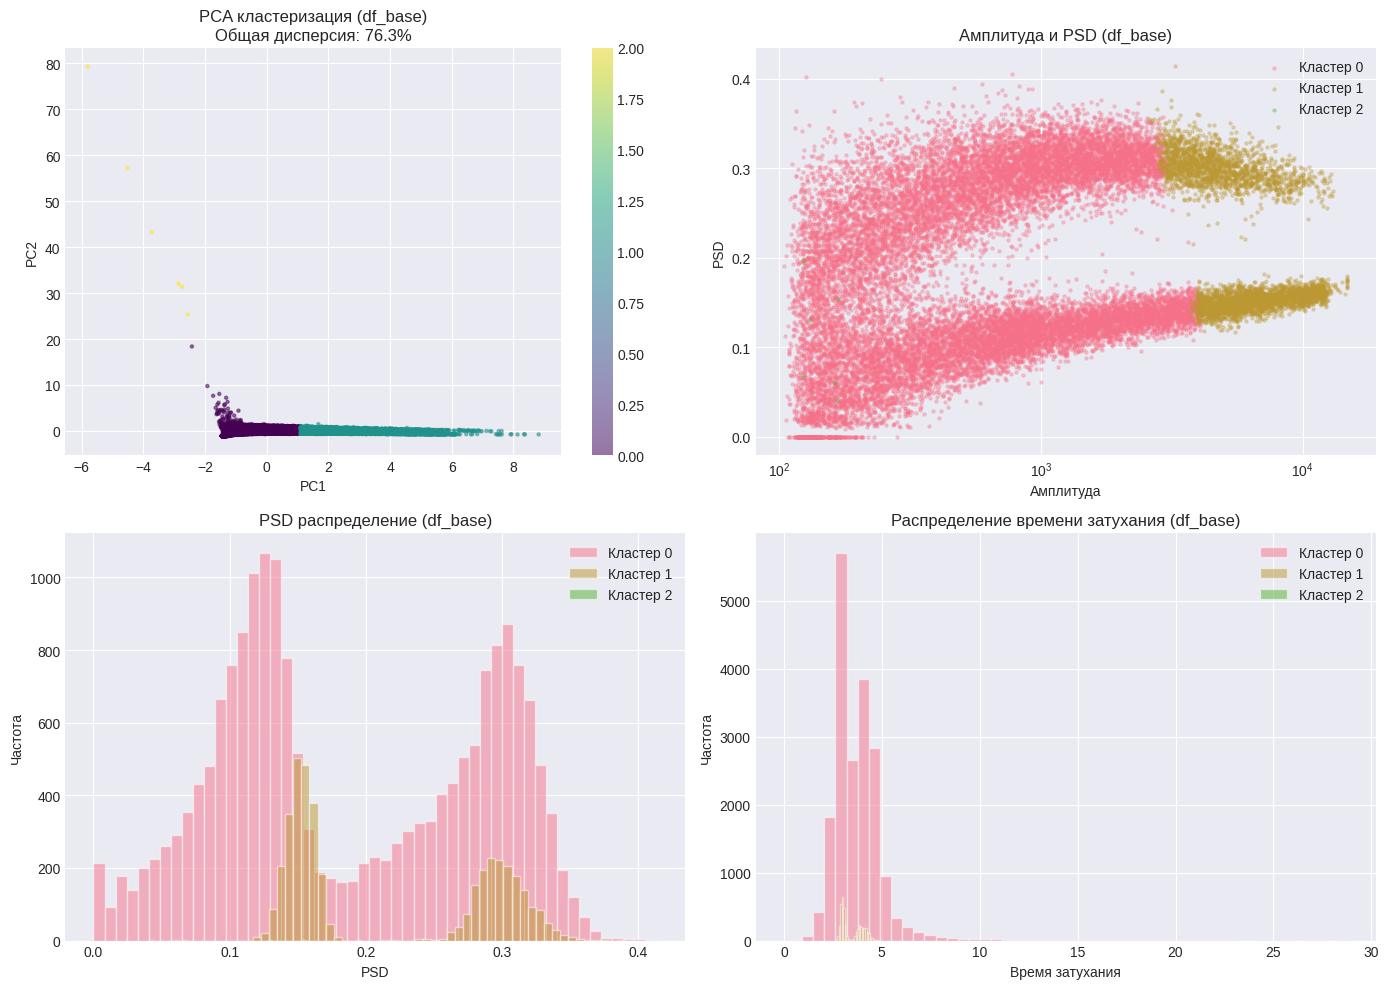

In [ ]:
plot_pca_loadings(df_base, X_pca, labels, pca, name = 'df_base')

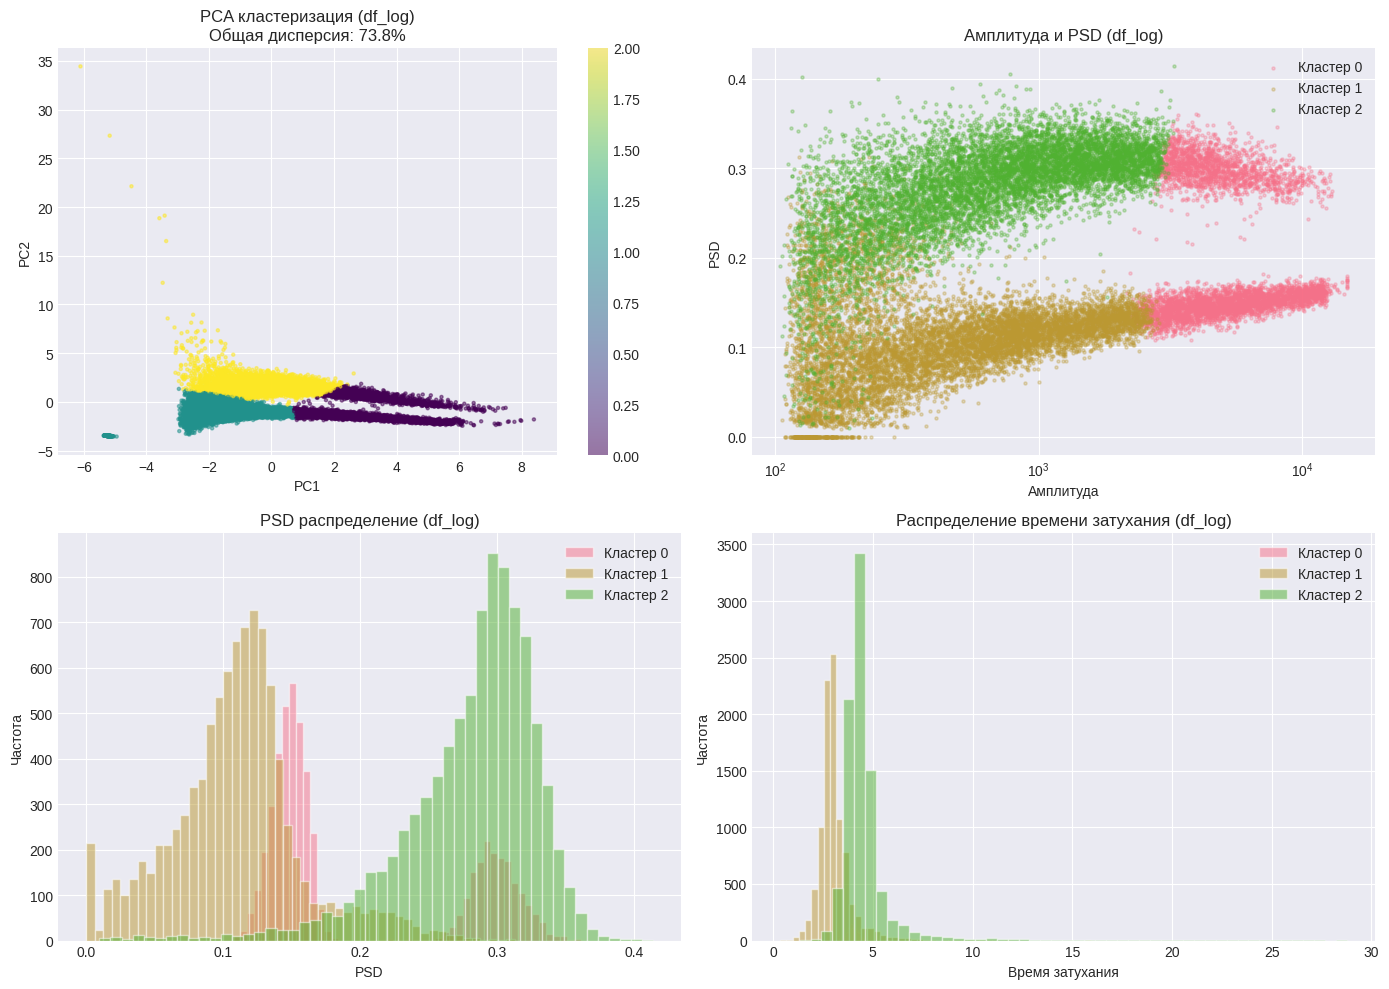

In [ ]:
plot_pca_loadings(df_base_log, X_pca_l, labels_l, pca_l, name = 'df_log')
#X_pca_l, pca_l, kmeans_l, labels_l = train_model(df_log, 'df_log')

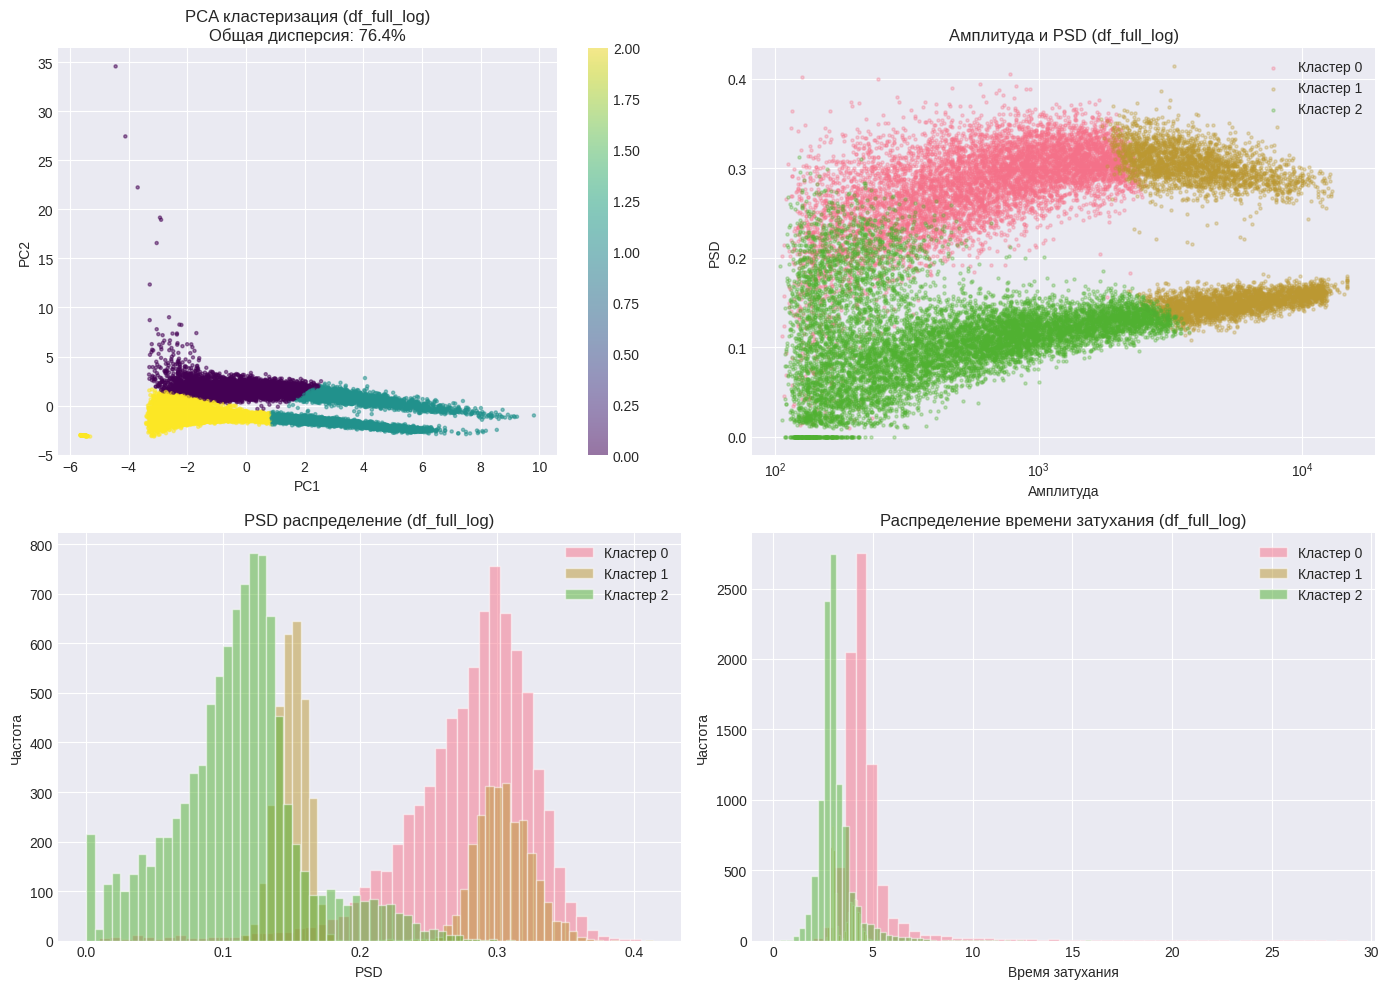

In [ ]:
plot_pca_loadings(df_full_log, X_pca_fl, labels_fl, pca_fl, name = 'df_full_log')

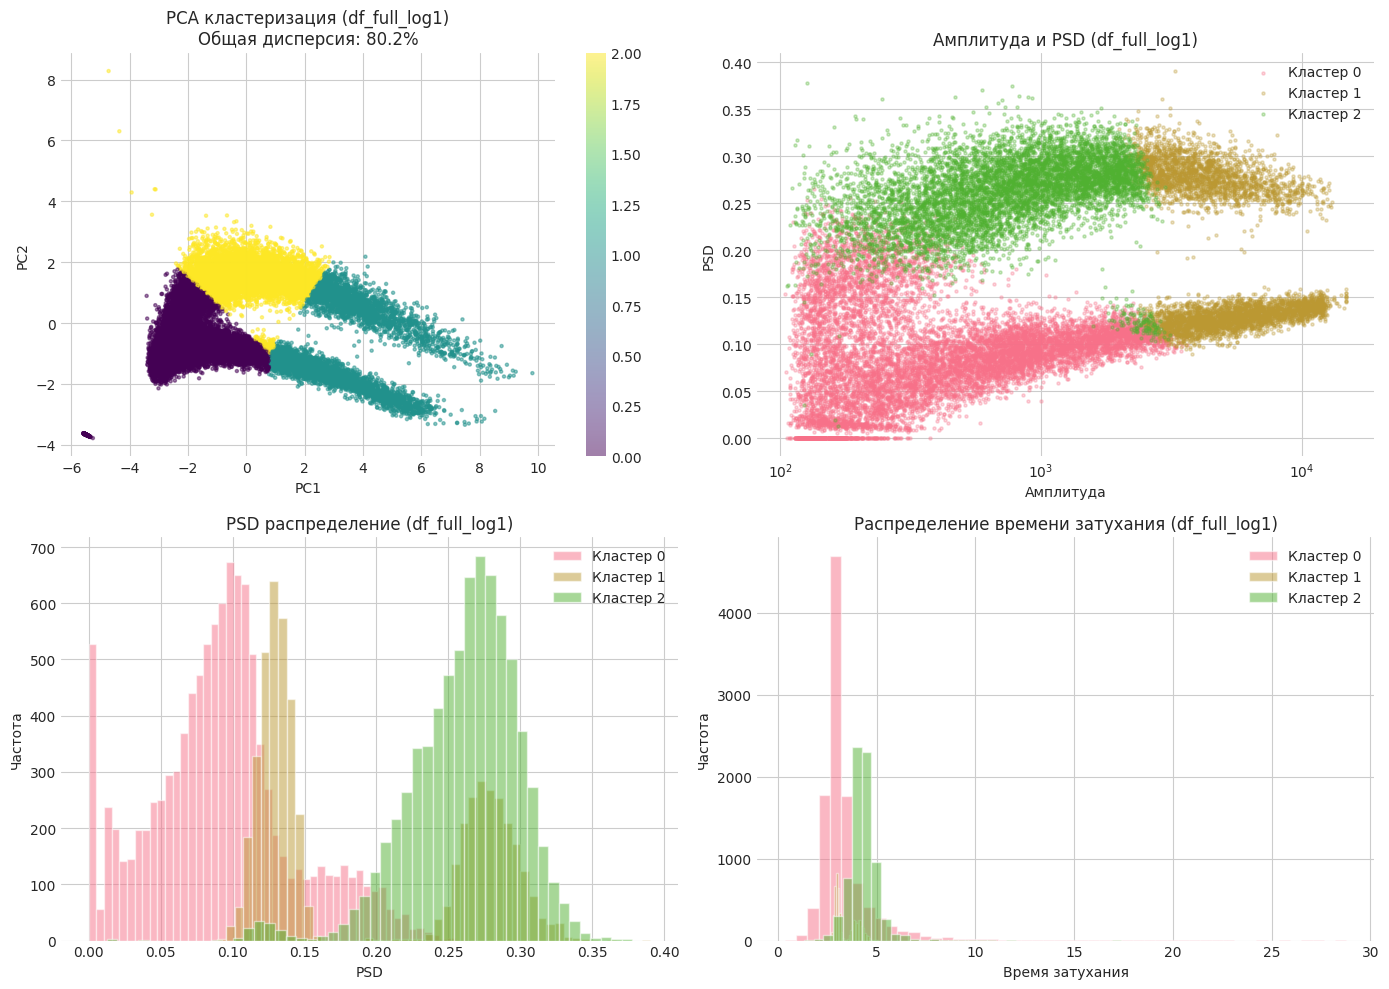

In [ ]:
plot_pca_loadings(df_full_log1, X_pca_fl1, labels_fl1, pca_fl1, name = 'df_full_log1')

Вывод:
- на полном наборе данных pca = 0.808 - лучше:
  - PC1: 62.58%  - первый компонент очень сильный
  - PC2: 18.01%  - второй компонент слабее
  - Сумма: 80.8% - два компонента сохраняют 81% информации
- df_full - даёт более полное представление о данных и лучше разделяет сигналы.
- также хороший силуэт на df_full_log и df_basic, но графически последний показывает не очень четкое разделение на 3 кластера.

## Оценка качества модели

In [ ]:
def convert_to_submission(X_pca, labels):
    # Перенумерация (0,1,2)
    unique = np.unique(labels)
    mapping = {old: new for new, old in enumerate(sorted(unique))}
    final_labels = np.array([mapping[l] for l in labels])

    # Оценка качества
    sil_score = silhouette_score(X_pca, final_labels)
    print(f"\nSilhouette score: {sil_score:.4f}")

    # Сохраняем результат на основе лучшей кластеризации
    submission = pd.DataFrame({
        'index': np.arange(len(final_labels)),
        'cluster': final_labels  # из df_base
    })
    # submission.to_csv('submission_baseline10fl.csv', index=False)
    # print("submission.csv сохранён!")
    # print(submission.head())

    return submission

### Анализ важности признаков

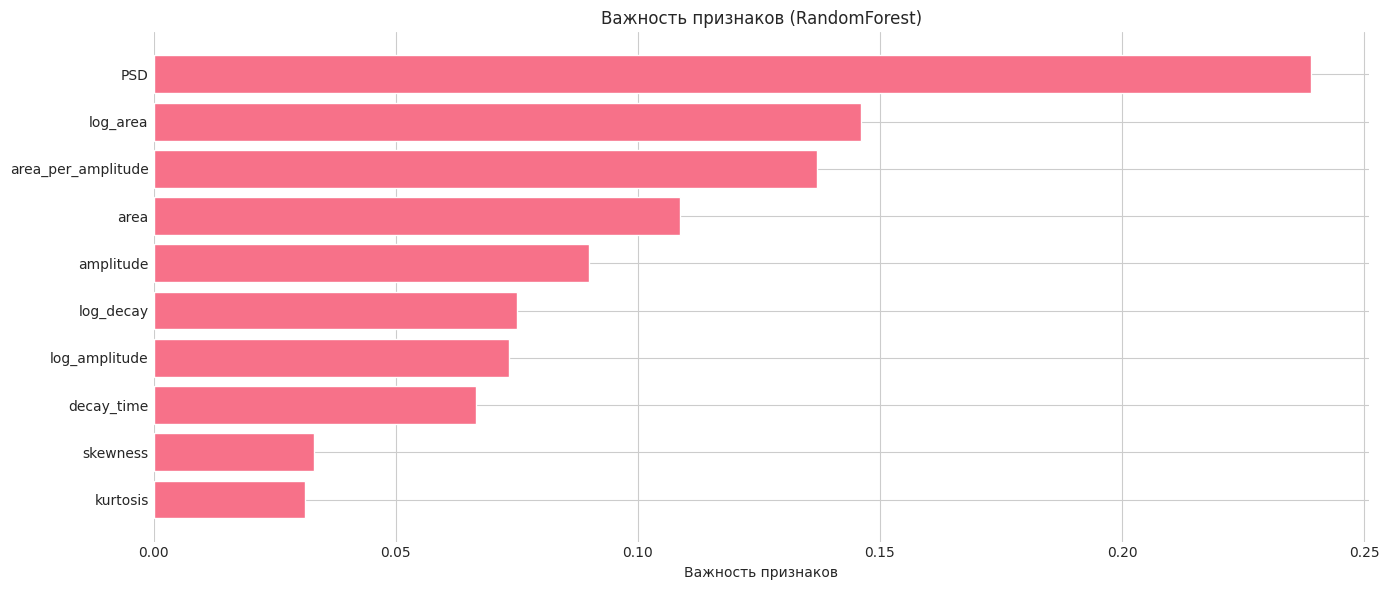


F-статистика:


,feature,f_score,p_value
1,area,24955.260829,0.000000e+00
0,amplitude,23001.924123,0.000000e+00
4,skewness,22135.324251,0.000000e+00
5,kurtosis,20622.246537,0.000000e+00
2,PSD,19442.953113,0.000000e+00
6,log_amplitude,17154.108741,0.000000e+00
9,area_per_amplitude,12699.989932,0.000000e+00
7,log_area,11141.127485,0.000000e+00
8,log_decay,5019.183087,0.000000e+00
3,decay_time,162.909736,5.440941e-71


In [ ]:
def feature_importance(df, labels):
    """  Анализ важности признаков """
    # Random Forest
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(df.fillna(0), labels)

    importance_rf = pd.DataFrame({
        'feature': df.columns,
        'importance_rf': rf.feature_importances_
    }).sort_values('importance_rf', ascending=True)

    # print("\nВажность признаков (RandomForest)")
    # print(importance_rf)

    fig, axes = plt.subplots(1, 1, figsize=(14, 6))
    axes.barh(importance_rf['feature'][:15], importance_rf['importance_rf'][:15])
    axes.set_xlabel('Важность признаков')
    axes.set_title('Важность признаков (RandomForest)')

    plt.tight_layout()
    #plt.savefig('feature_importance.png', dpi=150)
    plt.show()

    # Одномерный отбор признаков (ANOVA F-value)
    selector_f = SelectKBest(score_func=f_classif, k='all')
    selector_f.fit(df.fillna(0), labels)
    f_scores = pd.DataFrame({
        'feature': df.columns,
        'f_score': selector_f.scores_,
        'p_value': selector_f.pvalues_
    }).sort_values('f_score', ascending=False)

    print("\nF-статистика:")
    display(f_scores)

    return importance_rf, f_scores

# X_pca_l, labels_l
importance_rf, f_scores = feature_importance(df_full_log, labels_fl)

### Вывод:
- анализ важности признаков показал:
- PSD — самый важный признак по  RandomForest
   > что соответствует теории: PSD специально разработан для разделения гамма-квантов и нейтронов по форме сигнала;
- Area и Amplitude — самые важные по F-статистике - что также соответствует теории - линейная зависимость.
- новый признак ширины сигнала - оказался виторым по важности.
- 'skewness', 'kurtosis' имеют сильную линейную информативность, важны по F-статистике, улучшают PCA - оставляем.
- Оба метода показывают, что время затухания decay_time — самый слабый признак - большинство сигналов быстро затухают (decay_time < 4.3), что соответствует документации .
  > для сохранения информации о редких медленных сигналах, которые могут соответствовать нейтронам не будем удалять, к тому же в документации он отмечен важным параметром.\
  > проверила на данных - удаление любого из этих параметров ухудшает метрику - все оставляем
- для разделения на кластеров значение RandomForest более важно, так как учитывает нелинейные связи.

- на финальную модель берем весь набор признаков.

In [ ]:
%%time
submission_f = convert_to_submission(X_pca_f, labels_f)


Silhouette score: 0.4678
CPU times: user 1.97 s, sys: 1.46 s, total: 3.43 s
Wall time: 2.46 s


In [ ]:
%%time
# df_log
submission_l = convert_to_submission(X_pca_l, labels_l)


Silhouette score: 0.4731
CPU times: user 1.92 s, sys: 270 ms, total: 2.19 s
Wall time: 4.52 s


In [ ]:
%%time
submission = convert_to_submission(X_pca, labels)


Silhouette score: 0.6564
CPU times: user 2.18 s, sys: 277 ms, total: 2.46 s
Wall time: 3.28 s


In [ ]:
%%time
# df_full_log1
submission_fl1 = convert_to_submission(X_pca_fl1, labels_fl1)


Silhouette score: 0.4451
CPU times: user 1.88 s, sys: 605 ms, total: 2.49 s
Wall time: 1.99 s


In [ ]:
%%time
# df_full_log
submission_fl = convert_to_submission(X_pca_fl, labels_fl)
submission_fl.to_csv('submission_baseline10_fl.csv', index=False)
print("submission.csv сохранён!")
print(submission_fl.head())


Silhouette score: 0.4468
submission.csv сохранён!
   index  cluster
0      0        1
1      1        1
2      2        1
3      3        2
4      4        1
CPU times: user 6.74 s, sys: 1.91 s, total: 8.65 s
Wall time: 6.92 s


In [ ]:
df_full_log.columns

Index(['amplitude', 'area', 'PSD', 'decay_time', 'skewness', 'kurtosis',
       'log_amplitude', 'log_area', 'log_decay', 'area_per_amplitude'],
      dtype='object')

### Вывод:
- проверила на безлайне kmeans: с 2 short_gate 4-ре набора признаков:
- Silhouette score не коррелирует с submission score - при самом нихком значении первого - самуй лучший результат на сабмишн.
- **short_gate=10 лучше для полных log-признаков** (amplitude, area, PSD, decay_time, skewness, kurtosis)
  - **Score: 0.56701**
- **short_gate=9 лучше для базовых log-признаков** (без skewness, kurtosis):
  - Score: 0.53175
- Вообще и на short_gate = 10, и 9 можно получить и хорошие, и не очень результаты - очень зависит от набора признаков.
- Самый лучший результат на **short_gate=10 для full признаков логарифмированных**
- на финальную модель берем df_full_log:
 ```
 SHORT_GATE = 10
 FINAL_FEATURES = ['amplitude', 'area', 'PSD', 'decay_time', 'skewness', 'kurtosis', \
                  'log_amplitude', 'log_area', 'log_decay', 'area_per_amplitude']
 ```

## Подбор гиперпараметров лучшей модели
за основу берем: short_gate=10, полный набор признаков признаки (amplitude, area, PSD, decay_time)
- Также применим RobustScaller - для нормализации, так как он менее чувствителен к выбросам

In [ ]:
SHORT_GATE = 10
FINAL_FEATURES = ['amplitude', 'area', 'PSD', 'decay_time', 'skewness', 'kurtosis', \
                 'log_amplitude', 'log_area', 'log_decay', 'area_per_amplitude']

### Проверка моделей

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_full_log)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Модели для сравнения
models = {
    'KMeans': KMeans(n_clusters=3, random_state=42, n_init=10),
    'GaussianMixture': GaussianMixture(n_components=3, random_state=42),
    'Agglomerative': AgglomerativeClustering(n_clusters=3),
}

results = []
for name, model in models.items():
    print(f"\n{name}")
    labels = model.fit_predict(X_pca)
    unique = np.unique(labels)
    if len(unique) == 3:
        mapping = {old: new for new, old in enumerate(sorted(unique))}
        labels_final = np.array([mapping[l] for l in labels])

        sil_score = silhouette_score(X_pca, labels_final)
        cal_score = calinski_harabasz_score(X_pca, labels_final)
        results.append({
                'model': name,
                'sil_score': sil_score,
                'calinski_harabasz': cal_score,
                'labels': labels_final,})
        print(f"  Silhouette score: {sil_score:.4f}")
        print(f"  Calinski-Harabasz: {cal_score:.1f}")


KMeans
  Silhouette score: 0.4468
  Calinski-Harabasz: 23498.1

GaussianMixture
  Silhouette score: 0.3961
  Calinski-Harabasz: 14822.6

Agglomerative
  Silhouette score: 0.3749
  Calinski-Harabasz: 18036.5


In [ ]:
print("\nСравнение результатов")
results_df = pd.DataFrame(results)
display(results_df[['model', 'sil_score', 'calinski_harabasz']]
                  .sort_values('sil_score', ascending=False))


Сравнение результатов


,model,sil_score,calinski_harabasz
0,KMeans,0.446833,23498.141727
1,GaussianMixture,0.396107,14822.597551
2,Agglomerative,0.374852,18036.476775


### Проверка RobustScaler()

In [ ]:
def train_model(data, n_component = 2, name_data = FINAL_FEATURES):
    # Стандартизация и pca
    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(data)

    pca = PCA(n_components=n_component)
    X_pca = pca.fit_transform(X_scaled)
    print(f"Число выбранных компонент {name_data}:", pca.explained_variance_ratio_)
    print(f"Среднее значение {name_data}: pca = {pca.explained_variance_ratio_.sum():.3f}")
    # Кластеризация
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca)

    return X_pca, pca, kmeans, labels

In [ ]:
X_pca_rfl, pca_rfl, kmeans_rfl, labels_rfl = train_model(df_full_log, name_data = 'df_full_log')

Число выбранных компонент df_full_log: [0.8760229  0.08500849]
Среднее значение df_full_log: pca = 0.961


Вывод: при scaler = RobustScaler() - явное переобучение, используем:
```
BEST_CONFIG = {
    'features': ['amplitude', 'area', 'PSD', 'decay_time', 'skewness', 'kurtosis', \
                 'log_amplitude', 'log_area', 'log_decay', 'area_per_amplitude'],
    'scaler': StandardScaler(),  
    'n_components': 2,
    'short_gate': 10
}
```

### Подбор PCA-компонент

In [ ]:
# Посмотрим pca n_components
def train_model_best(data, n_component = 2, name_data = FINAL_FEATURES):
    # Стандартизация и pca
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(data)

    pca = PCA(n_components=n_component)
    X_pca = pca.fit_transform(X_scaled)
    print(f"\nЧисло выбранных компонент {name_data}:", pca.explained_variance_ratio_)
    print(f"Среднее значение {name_data}: pca = {pca.explained_variance_ratio_.sum():.3f}")

    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca)

    unique = np.unique(labels)
    mapping = {old: new for new, old in enumerate(sorted(unique))}
    labels_final = np.array([mapping[l] for l in labels])

    sil_score = silhouette_score(X_pca, labels_final)
    print(f"Silhouette score: {sil_score:.4f}")

    return X_pca, pca, kmeans, labels_final, sil_score

all_results = {}
for n_comp in [2, 3, 4, 5]:
    X_pca, pca, kmeans, labels_final, sil_score = train_model_best(df_full_log, n_component=n_comp,\
                                                              name_data='df_full_log')
    results[n_comp] = {
        'X_pca': X_pca,
        'pca': pca,
        'kmeans': kmeans,
        'labels': labels_final,
        'sil_score': sil_score
    }

# Доступ к результатам
# print("\nДоступ к результатам:")
# print(f"labels для n_components=3: {results[3]['labels'][:10]}")

comparison = pd.DataFrame([ {'n_components': n_comp,
                      'explained_var': results[n_comp]['pca'].explained_variance_ratio_.sum(),
                      'silhouette_score': results[n_comp]['sil_score'] }
                      for n_comp in results])
display(comparison.sort_values('silhouette_score', ascending=False))


Число выбранных компонент df_full_log: [0.54427207 0.21899867]
Среднее значение df_full_log: pca = 0.763
Silhouette score: 0.4468

Число выбранных компонент df_full_log: [0.54427207 0.21899867 0.12015579]
Среднее значение df_full_log: pca = 0.883
Silhouette score: 0.4297

Число выбранных компонент df_full_log: [0.54427207 0.21899867 0.12015579 0.0451618 ]
Среднее значение df_full_log: pca = 0.929
Silhouette score: 0.4118

Число выбранных компонент df_full_log: [0.54427207 0.21899867 0.12015579 0.0451618  0.03401088]
Среднее значение df_full_log: pca = 0.963
Silhouette score: 0.3920


,n_components,explained_var,silhouette_score
0,2,0.763271,0.446833
1,3,0.883427,0.429718
2,4,0.928588,0.411798
3,5,0.962599,0.391981


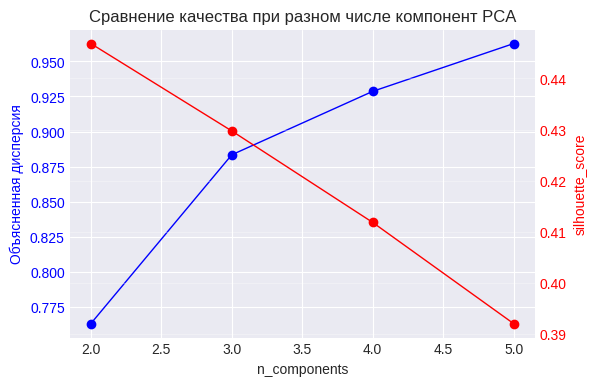

In [ ]:
fig, ax1 = plt.subplots(figsize=(6, 4))

x = comparison['n_components']
ax1.plot(x, comparison['explained_var'], 'bo-', label='Объясненная дисперсия', linewidth=1)
ax1.set_xlabel('n_components')
ax1.set_ylabel('Объясненная дисперсия', color='b')
ax1.tick_params(axis='y', labelcolor='b')

ax2 = ax1.twinx()
ax2.plot(x, comparison['silhouette_score'], 'ro-', label='silhouette_score', linewidth=1)
ax2.set_ylabel('silhouette_score', color='r')
ax2.tick_params(axis='y', labelcolor='r')

plt.title('Сравнение качества при разном числе компонент PCA')
plt.grid(True, alpha=0.3)
plt.show()

Вывод:
- анализ компонент показал, что: с увеличением числа компонент PCA с 2 до 5:
   - Объяснённая дисперсия выростает с 76% до 96%
   - Silhouette_score снижается с 0.45 до 0.39
- это говорит о лишнем 'шуме', который размывает кластеры
- Оптимальное значение n_components = 2.

### **Лучшие гиперпараметры модели**

In [ ]:
best_n = 2
best_model = results[best_n]
X_pca_best = best_model['X_pca']
pca_best = best_model['pca']
kmeans_best = best_model['kmeans']
labels_best = best_model['labels']
sil_score_best = best_model['sil_score']

print("Параметры модели KMeans:")
print(f"n_components: {best_n}")
print(f"PCA = {pca_best.explained_variance_ratio_.sum():.3f}")
print(f"PCA распределение по кластерам:{pca_best.explained_variance_ratio_}")
print(f"kmeans_clusters = {kmeans_best.n_clusters}")
print(f"sil_score = {sil_score_best:.4f}")



Параметры модели KMeans:
n_components: 2
PCA = 0.763
PCA распределение по кластерам:[0.54427207 0.21899867]
kmeans_clusters = 3
sil_score = 0.4468


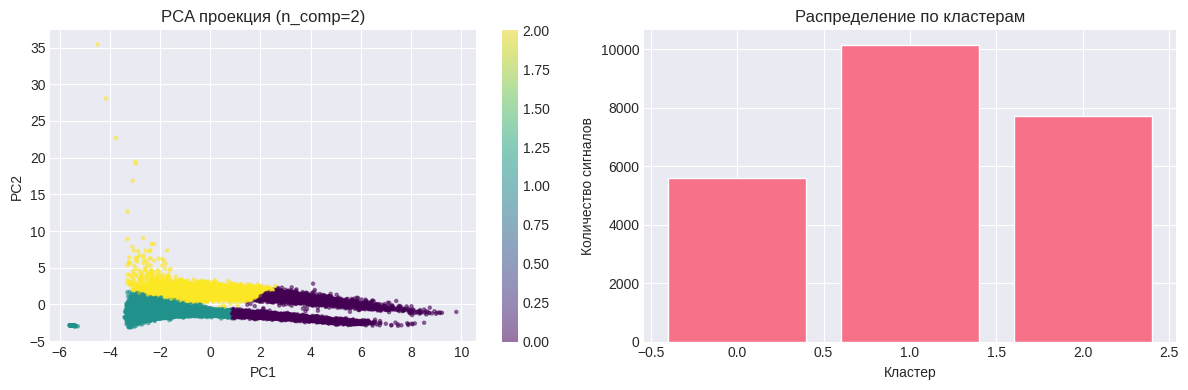

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# PCA проекция (первые 2 компоненты)
scatter = axes[0].scatter(X_pca_best[:, 0], X_pca_best[:, 1],
                          c=labels_best, cmap='viridis', alpha=0.5, s=5)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title(f'PCA проекция (n_comp={best_n})')
plt.colorbar(scatter, ax=axes[0])

# Гистограмма кластеров
axes[1].bar(range(3), [np.sum(labels_best == i) for i in range(3)])
axes[1].set_xlabel('Кластер')
axes[1].set_ylabel('Количество сигналов')
axes[1].set_title('Распределение по кластерам')

plt.tight_layout()
plt.savefig('clusters_n3.png', dpi=150)
plt.show()


### Вывод:
- Видно достаточно четкое разделение сигналов.
- Кластер 0 (фиолетовый): Маленький разброс, центрирован - вероятно, это основной тип сигналов (гамма-кванты)
- Кластеры 1 и 2 — более разбросаны
- Кластер 1 (зелёный): разброс по PC1 и PC2 - вероятно это сигналы, соответствующие второму типу частиц	(отличаются по форме сигнала)
- Кластер 2 (жёлтый): разброс по PC1 и PC2 -  шум/артефакты
- Качество разделения (silhouette = 0.45) -
   значительно лучше, чем в документе (0.027)
- отправляем на сабмит результаты кластеризации модели со следующими параметрами:
```
BEST_CONFIG = {
    'features': ['amplitude', 'area', 'PSD', 'decay_time', 'skewness', 'kurtosis', \
                 'log_amplitude', 'log_area', 'log_decay', 'area_per_amplitude'],
    'scaler': StandardScaler(),  
    'n_components': 2,
    'short_gate': 10
    'KMeans': n_clusters=3, random_state=42, n_init=10
}
```
- Итоговый результат: **submission_score = 0.567**

In [ ]:
def save_results(final_labels):
    # Сохраняем результат на основе лучшей кластеризации
    submission = pd.DataFrame({
        'index': np.arange(len(final_labels)),
        'cluster': final_labels  # из df_base
    })
    submission.to_csv('submission_10KM2.csv', index=False)
    print("submission.csv сохранён!")
    #print(submission.head())

    return submission
save_results(labels_best)

submission.csv сохранён!


,index,cluster
0,0,1
1,1,1
2,2,1
3,3,2
4,4,1
...,...,...
23474,23474,1
23475,23475,0
23476,23476,0
23477,23477,2


## **Итоговый вывод:**

В резудьтате исследований получила следующие результаты:
- **Финальная модель. Лучшая конфигурация**:
```
    'features': ['amplitude', 'area', 'PSD', 'decay_time', 'skewness', 'kurtosis', \
                 'log_amplitude', 'log_area', 'log_decay', 'area_per_amplitude'],
    'scaler': StandardScaler(),  
    'n_components': 2,
    'short_gate': 10
    'KMeans': n_clusters=3, random_state=42, n_init=10
```
   
- Качество кластеризации
  - **Silhouette score**: 0.45
  - **Submission score**: 0.567
  - по наблюдениям - наилучшие результаты получялились при **silhouette score** от 0.41 до 0.5 на этапе обучения, при более высоком занчении этого параметра - выявлялялось переобучение модели.

- PCA проекция показывает три различных кластера:
  - **Кластер 0 (фиолетовый)** — компактный, центральный (гамма-кванты)
  - **Кластер 1 (зелёный)** — разбросанный (нейтроны)
  - **Кластер 2 (жёлтый)** — разбросанный (шум/артефакты)

- Таким образом итоговая модель решает задачу кластеризации сигналов сцинтилляционного детектора, разделяя их на три типа:
  - гамма-кванты,
  - нейтроны,
  - шум.
  > Качество кластеризации в почти 17 раз, что значительно превосходит результаты, представленные в исходном документе, описывающем методику.

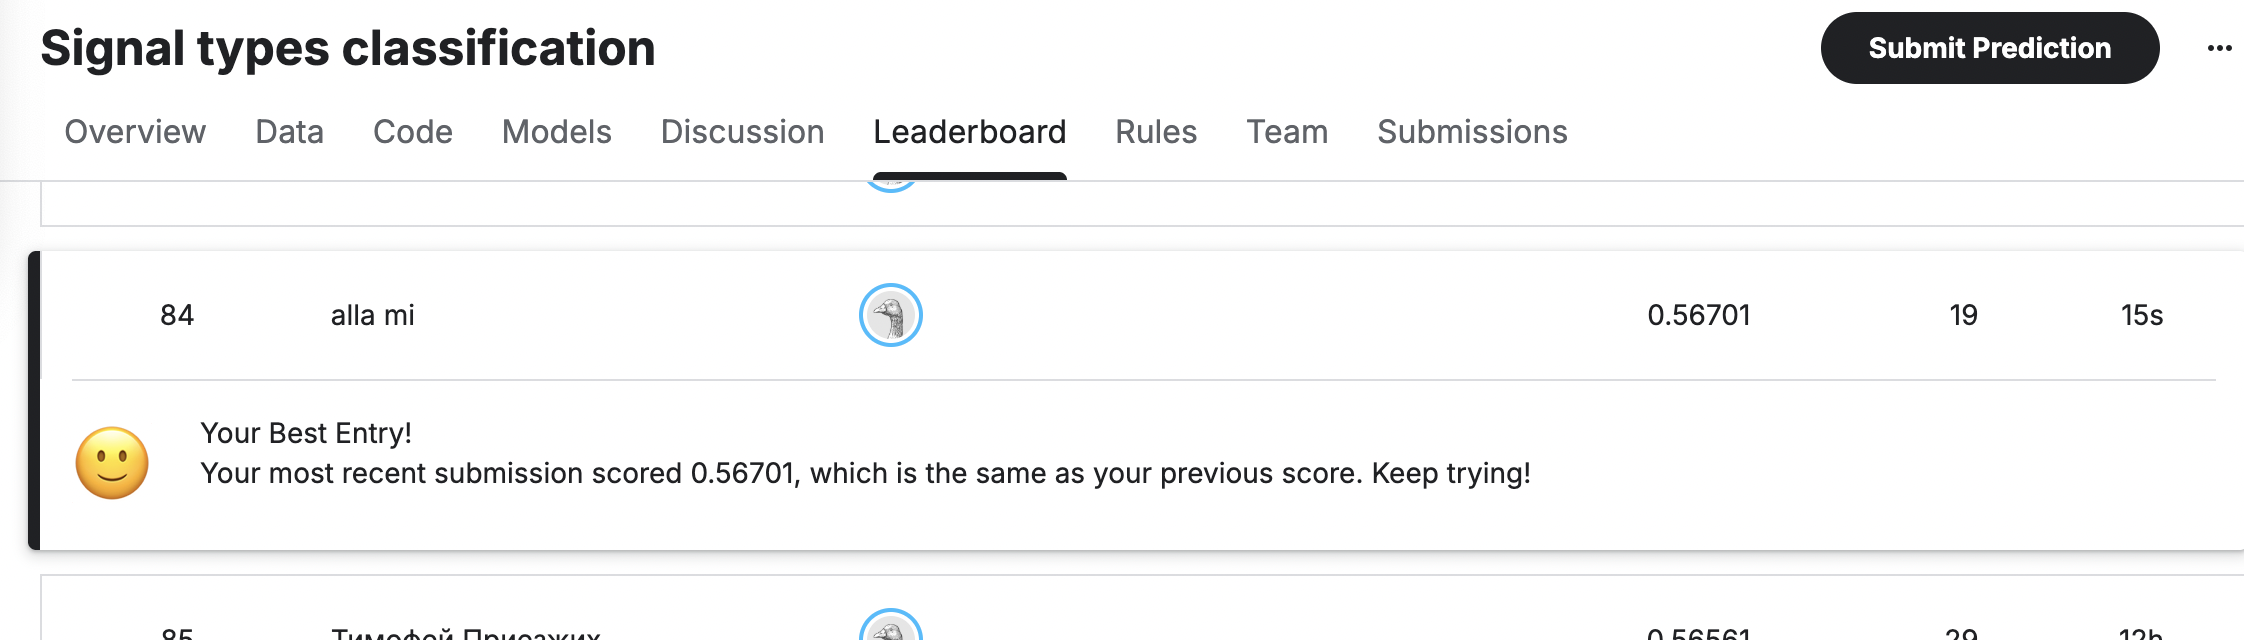